# "Is Quantitative Research Applicable to IDX Market?": A Microstructure Analysis on IDX Industry-Diversified Stocks using XGBoost and Investigation on Bandarmologi Bid-offer Alpha Decay

I started this project with a straightforward hypothesis: if I build a rigorous enough feature set from OHLCV microstructure data, I should be able to extract a predictive edge on IDX large-cap stocks. The Indonesia Stock Exchange is an emerging market which is retail-heavy, relatively lower analytical coverage on the quant side, and the assumption was that this inefficiency gap might be exploitable.

It documents every step of that search: how I ingested and cleaned the data, which academic microstructure estimators I used to proxy the bid-offer landscape, how I structured the ML validation, and most importantly what I actually found.

The pipeline built does the following:
1. Ingests OHLCV data (5-minute intraday + 2-year daily) from yfinance for a diversified IDX basket
2. Engineers market microstructure features proxied from OHLCV using peer-reviewed academic estimators
3. Detects order flow patterns using configurable rule-based logic
4. Aggregates intraday signals into daily features for model input
5. Trains an XGBoost classifier with strict walk-forward (no shuffling) to predict next-day continuation
6. Emits structured JSON outputs with explicit uncertainty bounds

> **Findings**
> 1. IDX is market-efficient at the surface level at least for large-cap, liquid ticker.
> 2. Finding edge is near-impossible when working with OHLCV-only surface data competing on names where institutional players are already active.
> 3. Without broker bid-offer information (real order-book flow, not OHLCV proxies), there is no extractable alpha from this approach.
> 4. Bandarmologi strategy (with solely using bid-offer) alpha decays when relying on historical data. Relying on historical bid-offer footprint patterns is a losing game because by the time the pattern is visible in historical data, the big player has already exited.

> **On methodology:** this walkthrough simulates an institutional alpha search in miniature from data ingestion to walk-forward validation.


---
## Environment Setup


In [1]:
!pip install -q yfinance xgboost plotly shap joblib lightgbm 2>&1 | tail -n 3

In [2]:
# Core
import os
import json
import warnings
from dataclasses import dataclass, field, asdict
from typing import Optional
from datetime import datetime, timedelta

# Data
import numpy as np
import pandas as pd
import yfinance as yf

# Modeling
import xgboost as xgb
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, accuracy_score, f1_score
)
import shap

# Viz
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from plotly.subplots import make_subplots

import joblib

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 60)
pd.set_option('display.width', 200)
np.random.seed(42)


---
## Section 1: System Architecture

### Pipeline Overview

```text
            ┌───────────────────────────────────────┐
            │   yfinance: 5-min bars (~60 days)     │
            │   yfinance: daily bars  (~2 years)    │
            └──────────────────┬────────────────────┘
                               ▼
            ┌──────────────────────────────────────┐
            │   [2] Ingestion → canonical schema   │
            │   [3] Validation                     │
            │   [4] Cleaning                       │
            └──────────────────┬───────────────────┘
                               ▼
        ┌──────────────────────┴──────────────────────┐
        ▼                                             ▼
  INTRADAY (5-min)                              DAILY
  [5] Microstructure features                   trend / vol regime
  [6] Tape reading proxies                      momentum, gap
  [7] Liquidity analysis
  [8] Order flow signals
        │                                             │
        └──────────────────────┬──────────────────────┘
                               ▼
            ┌──────────────────────────────────────┐
            │   Daily aggregation of intraday      │
            │   → ONE ROW PER (ticker, date)       │
            └──────────────────┬───────────────────┘
                               ▼
            ┌──────────────────────────────────────┐
            │   [9]  Label generation (T+1 ret)    │
            │   [10] XGBoost (TimeSeriesSplit)     │
            │   [11] Evaluation                    │
            │   [12] Feature importance + SHAP     │
            └──────────────────┬───────────────────┘
                               ▼
            ┌──────────────────────────────────────┐
            │   [13] Signal engine                 │
            │   [14] Structured JSON → LLM layer   │
            │   [15] Plotly dashboard              │
            └──────────────────────────────────────┘

```

### Global Configuration

All tunable parameters live in a single Config dataclass. This means I can re-run the entire investigation with a different basket, horizon, or model spec by changing one object.


In [3]:
@dataclass
class Config:
    tickers: list = field(default_factory=lambda:
     ['BBCA.JK','BBRI.JK','TLKM.JK','ASII.JK','GOTO.JK',])

    intraday_interval: str = '5m'
    intraday_period: str   = '60d'
    daily_period: str      = '2y'

    rolling_short: int = 6
    rolling_med: int   = 12
    rolling_long: int  = 24
    vol_window: int    = 20

    label_horizon_days: int = 1
    label_neutral_threshold: float = 0.003
    label_mode: str = 'binary'

    cv_splits: int = 5
    xgb_params: dict = field(default_factory=lambda: dict(
        n_estimators=400,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        min_child_weight=5,
        reg_alpha=0.1,
        reg_lambda=1.0,
        objective='binary:logistic',
        eval_metric='logloss',
        random_state=42,
        n_jobs=-1,
        tree_method='hist',
    ))

    output_dir: str = './output'
    model_path:  str = './output/xgb_model.joblib'

CFG = Config()
os.makedirs(CFG.output_dir, exist_ok=True)


### 1.5 Canonical Schema

Every downstream module assumes these column names exist

| Column | Type | Description |
|---|---|---|
| `ticker` | str | IDX symbol |
| `timestamp` | datetime64[ns, tz] | Bar close time (Asia/Jakarta) |
| `date` | date | Trading date (for daily aggregation) |
| `open`, `high`, `low`, `close` | float64 | OHLC |
| `volume` | float64 | Aggregated volume in this bar |
| `typical_price` | float64 | (H+L+C)/3 — for VWAP |
| `dollar_volume` | float64 | typical_price × volume |


---
## Section 2: Data Ingestion

Two resolutions are fetched per ticker: 5-minute intraday bars for microstructure feature engineering, and daily bars for the longer-horizon label and context features. The fetch_basket function handles both in one pass.


In [4]:
JAKARTA_TZ = 'Asia/Jakarta'

_YF_RENAME = {
    'Open': 'open',
    'High': 'high',
    'Low': 'low',
    'Close': 'close',
    'Adj Close': 'adj_close',
    'Volume': 'volume',
}


def _standardize_ohlcv(df: pd.DataFrame) -> pd.DataFrame:

    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)

    df = df.rename(columns=_YF_RENAME)

    # Ensure all expected columns exist
    for col in ['open', 'high', 'low', 'close', 'volume']:
        if col not in df.columns:
            df[col] = np.nan

    for col in ['open', 'high', 'low', 'close', 'volume']:
        df[col] = pd.to_numeric(df[col], errors='coerce')

    df = df.dropna(subset=['open', 'high', 'low', 'close'], how='all')

    return df


def fetch_intraday(ticker: str,
                   period: str = '60d',
                   interval: str = '5m') -> pd.DataFrame:
    try:
        raw = yf.download(
            ticker, period=period, interval=interval,
            progress=False, auto_adjust=False, threads=False
        )
    except Exception as e:
        print(f'  [ERROR] {ticker} intraday fetch failed: {e}')
        return pd.DataFrame()

    if raw is None or raw.empty:
        print(f'  [WARN] {ticker} intraday returned no rows')
        return pd.DataFrame()

    df = _standardize_ohlcv(raw)

    df.index = pd.to_datetime(df.index)
    if df.index.tz is None:
        df.index = df.index.tz_localize('UTC').tz_convert(JAKARTA_TZ)
    else:
        df.index = df.index.tz_convert(JAKARTA_TZ)

    df = df.reset_index().rename(columns={'index': 'timestamp', 'Datetime': 'timestamp', 'Date': 'timestamp'})

    ts_col = [c for c in df.columns if c in ('timestamp', 'Datetime', 'Date')]
    if ts_col and ts_col[0] != 'timestamp':
        df = df.rename(columns={ts_col[0]: 'timestamp'})

    df['ticker'] = ticker
    df['date']   = df['timestamp'].dt.tz_localize(None).dt.floor('D')

    df['typical_price'] = (df['high'] + df['low'] + df['close']) / 3.0
    df['dollar_volume'] = df['typical_price'] * df['volume']

    cols = ['ticker', 'timestamp', 'date',
            'open', 'high', 'low', 'close', 'volume',
            'typical_price', 'dollar_volume']
    return df[cols].sort_values('timestamp').reset_index(drop=True)


def fetch_daily(ticker: str, period: str = '2y') -> pd.DataFrame:
    try:
        raw = yf.download(
            ticker, period=period, interval='1d',
            progress=False, auto_adjust=False, threads=False
        )
    except Exception as e:
        print(f'  [ERROR] {ticker} daily fetch failed: {e}')
        return pd.DataFrame()

    if raw is None or raw.empty:
        print(f'  [WARN] {ticker} daily returned no rows')
        return pd.DataFrame()

    df = _standardize_ohlcv(raw)

    df = df.reset_index()
    ts_col = [c for c in df.columns if c in ('Date', 'Datetime', 'index')][0]
    df = df.rename(columns={ts_col: 'date'})
    df['date'] = pd.to_datetime(df['date'])

    df['ticker'] = ticker
    df['typical_price'] = (df['high'] + df['low'] + df['close']) / 3.0
    df['dollar_volume'] = df['typical_price'] * df['volume']

    keep = ['ticker', 'date', 'open', 'high', 'low', 'close']
    if 'adj_close' in df.columns:
        keep.append('adj_close')
    keep += ['volume', 'typical_price', 'dollar_volume']

    return df[keep].sort_values('date').reset_index(drop=True)


def fetch_basket(tickers: list,
                 intraday_period: str = '60d',
                 intraday_interval: str = '5m',
                 daily_period: str = '2y') -> tuple:
    intraday_parts, daily_parts = [], []
    print(f'Fetching basket: {tickers}')
    print('-' * 60)

    for tk in tickers:
        print(f'[{tk}]')
        intra = fetch_intraday(tk, intraday_period, intraday_interval)
        if not intra.empty:
            print(f'  intraday: {len(intra):>5} bars  '
                  f'({intra["timestamp"].min()} → {intra["timestamp"].max()})')
            intraday_parts.append(intra)

        daily = fetch_daily(tk, daily_period)
        if not daily.empty:
            print(f'  daily:    {len(daily):>5} bars  '
                  f'({daily["date"].min()} → {daily["date"].max()})')
            daily_parts.append(daily)

    intraday_df = pd.concat(intraday_parts, ignore_index=True) if intraday_parts else pd.DataFrame()
    daily_df    = pd.concat(daily_parts, ignore_index=True)    if daily_parts    else pd.DataFrame()

    print('-' * 60)
    print(f'Basket complete: {intraday_df["ticker"].nunique() if not intraday_df.empty else 0} '
          f'intraday tickers, {daily_df["ticker"].nunique() if not daily_df.empty else 0} daily tickers')
    return intraday_df, daily_df


### Run the Ingestion

Fetching the initial 5-ticker basket. I'll expand this later once I confirm the pipeline is clean.


In [5]:
intraday_df, daily_df = fetch_basket(
    tickers=CFG.tickers,
    intraday_period=CFG.intraday_period,
    intraday_interval=CFG.intraday_interval,
    daily_period=CFG.daily_period,
)


Fetching basket: ['BBCA.JK', 'BBRI.JK', 'TLKM.JK', 'ASII.JK', 'GOTO.JK']
------------------------------------------------------------
[BBCA.JK]
  intraday:  3617 bars  (2026-02-19 09:00:00+07:00 → 2026-05-21 09:30:00+07:00)
  daily:      478 bars  (2024-05-21 00:00:00 → 2026-05-21 00:00:00)
[BBRI.JK]
  intraday:  3615 bars  (2026-02-19 09:00:00+07:00 → 2026-05-21 09:30:00+07:00)
  daily:      478 bars  (2024-05-21 00:00:00 → 2026-05-21 00:00:00)
[TLKM.JK]
  intraday:  3614 bars  (2026-02-19 09:00:00+07:00 → 2026-05-21 09:30:00+07:00)
  daily:      478 bars  (2024-05-21 00:00:00 → 2026-05-21 00:00:00)
[ASII.JK]
  intraday:  3613 bars  (2026-02-19 09:00:00+07:00 → 2026-05-21 09:30:00+07:00)
  daily:      478 bars  (2024-05-21 00:00:00 → 2026-05-21 00:00:00)
[GOTO.JK]
  intraday:  3618 bars  (2026-02-19 09:00:00+07:00 → 2026-05-21 09:30:00+07:00)
  daily:      478 bars  (2024-05-21 00:00:00 → 2026-05-21 00:00:00)
------------------------------------------------------------
Basket complete

In [6]:

print('Intraday DF')
print(f'Shape: {intraday_df.shape}')
print(f'Columns: {list(intraday_df.columns)}')
print(f'Dtypes:\n{intraday_df.dtypes}')
print(f'\nPer-ticker bar counts:')
print(intraday_df.groupby("ticker").size().to_string())

print('\nDaily DF')
print(f'Shape: {daily_df.shape}')
print(f'Per-ticker bar counts:')
print(daily_df.groupby("ticker").size().to_string())

print('\nSampling')
sample = intraday_df[intraday_df['ticker']=='BBCA.JK'].head(5)
print(sample.to_string(index=False))


Intraday DF
Shape: (18077, 10)
Columns: ['ticker', 'timestamp', 'date', 'open', 'high', 'low', 'close', 'volume', 'typical_price', 'dollar_volume']
Dtypes:
Price
ticker                                 object
timestamp        datetime64[ns, Asia/Jakarta]
date                           datetime64[ns]
open                                  float64
high                                  float64
low                                   float64
close                                 float64
volume                                  int64
typical_price                         float64
dollar_volume                         float64
dtype: object

Per-ticker bar counts:
ticker
ASII.JK    3613
BBCA.JK    3617
BBRI.JK    3615
GOTO.JK    3618
TLKM.JK    3614

Daily DF
Shape: (2390, 10)
Per-ticker bar counts:
ticker
ASII.JK    478
BBCA.JK    478
BBRI.JK    478
GOTO.JK    478
TLKM.JK    478

Sampling
 ticker                 timestamp       date   open   high    low  close  volume  typical_price  dollar_volume

---
## Basket Expansion

### Why I Expanded the Basket

My initial 5-ticker run revealed a small sampling problem with ~140 features and only ~1,500-1,800 effective training rows, the model is operating in the small-data danger zone. A homogeneous basket of large-cap banks also masks a structural problem in the features which made the model learns to recognize ticker identity rather than signal.

Expanding to 15 tickers across 9 sectors solves both problems at once: more training rows, and more varied microstructure regimes that force the model to generalize.

### Ticker Selection

I selected names by three criteria:
- **Liquidity**: all are in or near the LQ45 / IDX30 by transaction value
- **Sector spread**: 9 sectors so the model sees genuinely different microstructure regimes
- **Excluding HSC stocks**: BREN and DSSA were excluded because both were removed from LQ45 in April 2026 for High Shareholding Concentration, which would introduce a structural bias into any historical pattern analysis

| Sector | Tickers |
|---|---|
| Banking | BBCA, BBRI, BMRI, BBNI |
| Telecom | TLKM |
| Conglomerate | ASII |
| Consumer staples | UNVR, ICBP |
| Tobacco | GGRM |
| Mining / Energy | ADRO, INCO, ANTM |
| Tech | GOTO |
| Property | BSDE |
| Pharma | KLBF |


In [7]:
EXPANDED_BASKET = [
    # Banking (HIMBARA)
    'BBCA.JK', 'BBRI.JK', 'BMRI.JK', 'BBNI.JK',
    # Telecom
    'TLKM.JK',
    # Conglomerate
    'ASII.JK',
    # Consumer staples
    'UNVR.JK', 'ICBP.JK',
    # Tobacco
    'GGRM.JK',
    # Mining / Energy
    'ADRO.JK', 'INCO.JK', 'ANTM.JK',
    # Tech
    'GOTO.JK',
    # Property
    'BSDE.JK',
    # Pharma
    'KLBF.JK',
]

print(f'Expanded basket: {len(EXPANDED_BASKET)} tickers')
for tk in EXPANDED_BASKET:
    print(f'  {tk}')

CFG.tickers = EXPANDED_BASKET


Expanded basket: 15 tickers
  BBCA.JK
  BBRI.JK
  BMRI.JK
  BBNI.JK
  TLKM.JK
  ASII.JK
  UNVR.JK
  ICBP.JK
  GGRM.JK
  ADRO.JK
  INCO.JK
  ANTM.JK
  GOTO.JK
  BSDE.JK
  KLBF.JK


In [8]:
# Re-fetch with the expanded basket
print('Fetching expanded basket')

intraday_df, daily_df = fetch_basket(
    tickers=CFG.tickers,
    intraday_period=CFG.intraday_period,
    intraday_interval=CFG.intraday_interval,
    daily_period=CFG.daily_period,
)


Fetching expanded basket
Fetching basket: ['BBCA.JK', 'BBRI.JK', 'BMRI.JK', 'BBNI.JK', 'TLKM.JK', 'ASII.JK', 'UNVR.JK', 'ICBP.JK', 'GGRM.JK', 'ADRO.JK', 'INCO.JK', 'ANTM.JK', 'GOTO.JK', 'BSDE.JK', 'KLBF.JK']
------------------------------------------------------------
[BBCA.JK]
  intraday:  3617 bars  (2026-02-19 09:00:00+07:00 → 2026-05-21 09:30:00+07:00)
  daily:      478 bars  (2024-05-21 00:00:00 → 2026-05-21 00:00:00)
[BBRI.JK]
  intraday:  3615 bars  (2026-02-19 09:00:00+07:00 → 2026-05-21 09:30:00+07:00)
  daily:      478 bars  (2024-05-21 00:00:00 → 2026-05-21 00:00:00)
[BMRI.JK]
  intraday:  3619 bars  (2026-02-19 09:00:00+07:00 → 2026-05-21 09:30:00+07:00)
  daily:      478 bars  (2024-05-21 00:00:00 → 2026-05-21 00:00:00)
[BBNI.JK]
  intraday:  3617 bars  (2026-02-19 09:00:00+07:00 → 2026-05-21 09:30:00+07:00)
  daily:      478 bars  (2024-05-21 00:00:00 → 2026-05-21 00:00:00)
[TLKM.JK]
  intraday:  3614 bars  (2026-02-19 09:00:00+07:00 → 2026-05-21 09:30:00+07:00)
  daily: 

In [9]:
# Define minimum acceptable data quality per ticker
MIN_DAILY_BARS    = 100
MIN_INTRADAY_BARS = 200

print(f'\nPer-ticker data availability')
print(f'{"ticker":<10} {"daily_bars":>10} {"intraday_bars":>14} {"status":>10}')

survivors_daily    = set()
survivors_intraday = set()
failures = []

if not daily_df.empty:
    daily_counts = daily_df.groupby('ticker').size().to_dict()
else:
    daily_counts = {}

if not intraday_df.empty:
    intraday_counts = intraday_df.groupby('ticker').size().to_dict()
else:
    intraday_counts = {}

for tk in CFG.tickers:
    nd = daily_counts.get(tk, 0)
    ni = intraday_counts.get(tk, 0)
    verdict = 'OK' if nd >= MIN_DAILY_BARS else 'DROP'
    if verdict == 'OK':
        survivors_daily.add(tk)
        if ni >= MIN_INTRADAY_BARS:
            survivors_intraday.add(tk)
    else:
        failures.append((tk, nd, ni))
    print(f'{tk:<10} {nd:>10} {ni:>14} {verdict:>10}')

# Prune
survivors = sorted(survivors_daily)
print(f'\nSurvivors (sufficient daily data): {len(survivors)}/{len(CFG.tickers)}')
print(f'  Daily-only:        {sorted(survivors_daily - survivors_intraday)}')
print(f'  Daily + intraday:  {sorted(survivors_intraday)}')
if failures:
    print(f'\nDropped:')
    for tk, nd, ni in failures:
        print(f'  {tk}: daily={nd}, intraday={ni}')

# Trim to survivors
if not daily_df.empty:
    daily_df = daily_df[daily_df['ticker'].isin(survivors)].reset_index(drop=True)
if not intraday_df.empty:
    intraday_df = intraday_df[intraday_df['ticker'].isin(survivors)].reset_index(drop=True)

# Update CFG
CFG.tickers = survivors
print(f'\nFinal basket: {CFG.tickers}')
print(f'Intraday shape: {intraday_df.shape}')
print(f'Daily    shape: {daily_df.shape}')



Per-ticker data availability
ticker     daily_bars  intraday_bars     status
BBCA.JK           478           3617         OK
BBRI.JK           478           3615         OK
BMRI.JK           478           3619         OK
BBNI.JK           478           3617         OK
TLKM.JK           478           3614         OK
ASII.JK           478           3613         OK
UNVR.JK           478           3613         OK
ICBP.JK           478           3605         OK
GGRM.JK           478           3454         OK
ADRO.JK           478           3615         OK
INCO.JK           478           3613         OK
ANTM.JK           478           3618         OK
GOTO.JK           478           3618         OK
BSDE.JK           478           3559         OK
KLBF.JK           478           3603         OK

Survivors (sufficient daily data): 15/15
  Daily-only:        []
  Daily + intraday:  ['ADRO.JK', 'ANTM.JK', 'ASII.JK', 'BBCA.JK', 'BBNI.JK', 'BBRI.JK', 'BMRI.JK', 'BSDE.JK', 'GGRM.JK', 'GOTO.JK', 'ICB

---
## Section 3: Data Validation

I built a formal validation layer that flags both hard violations (data corruption that must be removed) and soft violations (suspicious but potentially real prices) separately.


In [10]:
# Note: post-close auction extends a bit.
IDX_SESSION_START_HOUR = 9
IDX_SESSION_END_HOUR   = 16


def _coerce_time_col(df: pd.DataFrame, time_col: str) -> pd.DataFrame:
    if time_col not in df.columns:
        return df
    if df[time_col].dtype == object:
        df = df.copy()
        # If tz-aware timestamps slipped in as object dtype, preserve tz
        df[time_col] = pd.to_datetime(df[time_col], errors='coerce')
    return df


def validate_ohlcv(df: pd.DataFrame,
                   is_intraday: bool = True,
                   session_check: bool = True) -> pd.DataFrame:
    if df.empty:
        return df.copy()

    out = df.copy()
    time_col = 'timestamp' if is_intraday else 'date'
    out = _coerce_time_col(out, time_col)
    out = out.sort_values(['ticker', time_col]).reset_index(drop=True)
    out['flag_dup_ts'] = out.duplicated(subset=['ticker', time_col], keep=False)
    prev_time = out.groupby('ticker')[time_col].shift(1)
    out['flag_not_monotonic'] = (out[time_col] <= prev_time).fillna(False)

    # Row-level invariants
    out['flag_hl_inverted']  = out['high'] < out['low']
    out['flag_oc_outside_hl'] = (
        (out['open']  > out['high']) | (out['open']  < out['low']) |
        (out['close'] > out['high']) | (out['close'] < out['low'])
    )
    out['flag_nonpos_price'] = (
        (out['open'] <= 0) | (out['high'] <= 0) |
        (out['low']  <= 0) | (out['close'] <= 0)
    )
    out['flag_neg_volume']   = out['volume'] < 0
    out['flag_nan_ohlcv']    = out[['open','high','low','close','volume']].isna().any(axis=1)

    # Session-hours check (intraday only)
    if is_intraday and session_check:
        hours = out['timestamp'].dt.hour
        out['flag_outside_session'] = ~hours.between(IDX_SESSION_START_HOUR,
                                                    IDX_SESSION_END_HOUR - 1)
    else:
        out['flag_outside_session'] = False

    # Aggregate severity flags
    hard_flags = ['flag_dup_ts', 'flag_not_monotonic', 'flag_hl_inverted',
                  'flag_nonpos_price', 'flag_neg_volume', 'flag_nan_ohlcv']
    soft_flags = ['flag_oc_outside_hl', 'flag_outside_session']

    out['flag_hard'] = out[hard_flags].any(axis=1)
    out['flag_soft'] = out[soft_flags].any(axis=1)

    return out


def validation_report(validated: pd.DataFrame, label: str = '') -> pd.DataFrame:
    if validated.empty:
        print(f'[{label}] empty frame — nothing to validate')
        return pd.DataFrame()

    flag_cols = [c for c in validated.columns if c.startswith('flag_')
                 and c not in ('flag_hard', 'flag_soft')]

    by_ticker = (validated.groupby('ticker')[flag_cols + ['flag_hard', 'flag_soft']]
                          .sum().astype(int))
    by_ticker['total_rows'] = validated.groupby('ticker').size()

    # Move total_rows to front
    by_ticker = by_ticker[['total_rows'] + flag_cols + ['flag_hard', 'flag_soft']]

    print(f'Validation Report: {label}')
    print(by_ticker.to_string())
    print()
    total_hard = int(validated['flag_hard'].sum())
    total_soft = int(validated['flag_soft'].sum())
    total_rows = len(validated)
    print(f'Hard violations: {total_hard:>6} / {total_rows} '
          f'({100*total_hard/total_rows:.2f}%)')
    print(f'Soft violations: {total_soft:>6} / {total_rows} '
          f'({100*total_soft/total_rows:.2f}%)')
    return by_ticker


### Run Validation on Both Frames

Validating both intraday and daily data before any cleaning. The report tells me exactly what I'm dealing with.


In [11]:
# Validate both frames
intraday_validated = validate_ohlcv(intraday_df, is_intraday=True,  session_check=True)
daily_validated    = validate_ohlcv(daily_df,    is_intraday=False, session_check=False)

intraday_report = validation_report(intraday_validated, label='INTRADAY (5m)')
print()
daily_report    = validation_report(daily_validated,    label='DAILY')


Validation Report: INTRADAY (5m)
Price    total_rows  flag_dup_ts  flag_not_monotonic  flag_hl_inverted  flag_oc_outside_hl  flag_nonpos_price  flag_neg_volume  flag_nan_ohlcv  flag_outside_session  flag_hard  flag_soft
ticker                                                                                                                                                                                    
ADRO.JK        3615            0                   0                 0                   0                  0                0               0                   166          0        166
ANTM.JK        3618            0                   0                 0                   0                  0                0               0                   166          0        166
ASII.JK        3613            0                   0                 0                   0                  0                0               0                   164          0        164
BBCA.JK        3617            0

---
## Section 4: Data Cleaning

The cleaner returns two things:
1. A cleaned DataFrame ready for feature engineering
2. A structured func cleaning_report recording exactly what was changed and why


In [12]:
DEFAULT_CLEANING_POLICY = {
    'drop_hard_violations': True,
    'dedup_keep': 'last',
    'fill_nan_ohlc': True,
    'fill_nan_volume_with': 0.0,
    'keep_soft_violations': True,
    'mark_stale_bars': True,
}

def clean_ohlcv(validated: pd.DataFrame,
                policy: dict = None,
                is_intraday: bool = True,
                label: str = '') -> tuple:
    if policy is None:
        policy = DEFAULT_CLEANING_POLICY.copy()
    if validated.empty:
        return validated.copy(), {'label': label, 'note': 'empty input'}

    time_col = 'timestamp' if is_intraday else 'date'
    df = validated.copy()

    # coerce time column to datetime64
    df = _coerce_time_col(df, time_col)

    n_in = len(df)

    report = {
        'label': label,
        'rows_in': n_in,
        'per_ticker_in': df.groupby('ticker').size().to_dict(),
        'actions': [],
    }

    # 1. handle duplicates explicitly (per policy.dedup_keep)
    dup_mask = df.duplicated(subset=['ticker', time_col], keep=policy['dedup_keep'])
    n_dup_drop = int(dup_mask.sum())
    if n_dup_drop:
        df = df.loc[~dup_mask].reset_index(drop=True)
        report['actions'].append({
            'step': 'dedup', 'rows_removed': n_dup_drop,
            'keep_rule': policy['dedup_keep']
        })
        # Re-flag dup_ts since duplicates are now resolved
        df['flag_dup_ts'] = False

    # 2. forward-fill NaN OHLC if policy says so
    n_filled = 0
    if policy['fill_nan_ohlc']:
        # Mark stale BEFORE filling
        df['is_stale'] = df['flag_nan_ohlcv'].fillna(False) if policy['mark_stale_bars'] else False
        # Forward-fill within ticker (no cross-ticker contamination)
        ohlc_cols = ['open', 'high', 'low', 'close']
        before_nan = df[ohlc_cols].isna().sum().sum()
        df[ohlc_cols] = df.groupby('ticker')[ohlc_cols].ffill()
        after_nan = df[ohlc_cols].isna().sum().sum()
        n_filled = int(before_nan - after_nan)
        if n_filled:
            report['actions'].append({
                'step': 'ffill_ohlc', 'cells_filled': n_filled
            })
    else:
        df['is_stale'] = False

    # 3. volume NaN handling
    fill_val = policy['fill_nan_volume_with']
    n_vol_filled = int(df['volume'].isna().sum())
    if not pd.isna(fill_val) and n_vol_filled:
        df['volume'] = df['volume'].fillna(fill_val)
        df['dollar_volume'] = df['dollar_volume'].fillna(0.0)
        report['actions'].append({
            'step': 'fill_volume', 'cells_filled': n_vol_filled,
            'fill_value': fill_val
        })

    # Recompute typical_price and dollar_volume for forward-filled rows so downstream consumers see consistent values
    if n_filled:
        df['typical_price'] = (df['high'] + df['low'] + df['close']) / 3.0
        df['dollar_volume'] = df['typical_price'] * df['volume']

    # 4. re-validate residual hard violations for anything ffill didn't fix.
    df['flag_nan_ohlcv']  = df[['open','high','low','close','volume']].isna().any(axis=1)
    df['flag_hl_inverted']  = df['high'] < df['low']
    df['flag_nonpos_price'] = (
        (df['open'] <= 0) | (df['high'] <= 0) |
        (df['low']  <= 0) | (df['close'] <= 0)
    )
    df['flag_neg_volume'] = df['volume'] < 0
    df['flag_not_monotonic'] = df.groupby('ticker')[time_col].shift(1).gt(df[time_col]).fillna(False)

    hard_cols_residual = ['flag_hl_inverted', 'flag_nonpos_price',
                          'flag_neg_volume', 'flag_nan_ohlcv', 'flag_not_monotonic']
    residual_hard = df[hard_cols_residual].any(axis=1)
    n_residual_drop = int(residual_hard.sum())
    if policy['drop_hard_violations'] and n_residual_drop:
        df = df.loc[~residual_hard].reset_index(drop=True)
        report['actions'].append({
            'step': 'drop_hard', 'rows_removed': n_residual_drop
        })

    # 5. prune validation columns
    keep_cols = ['ticker', time_col]
    if is_intraday and 'date' in df.columns and time_col == 'timestamp':
        keep_cols.append('date')
    keep_cols += ['open','high','low','close','volume','typical_price','dollar_volume']
    if 'adj_close' in df.columns:
        keep_cols.insert(keep_cols.index('open'), 'adj_close')
    # Retain soft flag and is_stale so downstream code can choose to react
    if policy['keep_soft_violations'] and 'flag_soft' in df.columns:
        keep_cols.append('flag_soft')
    if 'is_stale' in df.columns:
        keep_cols.append('is_stale')

    clean_df = df[keep_cols].sort_values(['ticker', time_col]).reset_index(drop=True)

    # output
    report['rows_out'] = len(clean_df)
    report['rows_removed_total'] = n_in - len(clean_df)
    report['per_ticker_out'] = clean_df.groupby('ticker').size().to_dict()
    report['soft_flag_retained'] = (
        int(clean_df['flag_soft'].sum()) if 'flag_soft' in clean_df.columns else 0
    )
    report['stale_bars_retained'] = (
        int(clean_df['is_stale'].sum()) if 'is_stale' in clean_df.columns else 0
    )

    return clean_df, report


def print_cleaning_report(report: dict):
    print(f' Cleaning Report: {report.get("label","")}')
    print(f'Rows in:  {report.get("rows_in", 0):>6}')
    print(f'Rows out: {report.get("rows_out", 0):>6}')
    print(f'Removed:  {report.get("rows_removed_total", 0):>6}')
    print()
    actions = report.get('actions', [])
    if not actions:
        print('No cleaning actions taken.')
    else:
        for a in actions:
            step = a.pop('step')
            details = ', '.join(f'{k}={v}' for k, v in a.items())
            print(f'  [{step:<14}] {details}')
    print(f'\nSoft flags retained: {report.get("soft_flag_retained", 0)}')
    print(f'Stale bars retained: {report.get("stale_bars_retained", 0)}')
    pt_out = report.get('per_ticker_out', {})
    if pt_out:
        print(f'\nPer-ticker rows out:')
        for tk, n in sorted(pt_out.items()):
            print(f'  {tk:<12} {n:>6}')


### Apply Cleaning

Running both frames through the cleaner and printing the audit report.


In [13]:
# Clean both frames
intraday_clean, intraday_clean_report = clean_ohlcv(
    intraday_validated, is_intraday=True,  label='INTRADAY (5m)'
)
daily_clean, daily_clean_report = clean_ohlcv(
    daily_validated, is_intraday=False, label='DAILY'
)

print_cleaning_report(intraday_clean_report)
print()
print_cleaning_report(daily_clean_report)


 Cleaning Report: INTRADAY (5m)
Rows in:   53993
Rows out:  53993
Removed:       0

No cleaning actions taken.

Soft flags retained: 2396
Stale bars retained: 0

Per-ticker rows out:
  ADRO.JK        3615
  ANTM.JK        3618
  ASII.JK        3613
  BBCA.JK        3617
  BBNI.JK        3617
  BBRI.JK        3615
  BMRI.JK        3619
  BSDE.JK        3559
  GGRM.JK        3454
  GOTO.JK        3618
  ICBP.JK        3605
  INCO.JK        3613
  KLBF.JK        3603
  TLKM.JK        3614
  UNVR.JK        3613

 Cleaning Report: DAILY
Rows in:    7170
Rows out:   7170
Removed:       0

No cleaning actions taken.

Soft flags retained: 0
Stale bars retained: 0

Per-ticker rows out:
  ADRO.JK         478
  ANTM.JK         478
  ASII.JK         478
  BBCA.JK         478
  BBNI.JK         478
  BBRI.JK         478
  BMRI.JK         478
  BSDE.JK         478
  GGRM.JK         478
  GOTO.JK         478
  ICBP.JK         478
  INCO.JK         478
  KLBF.JK         478
  TLKM.JK         478
  UNVR

In [14]:
# Re-validate the cleaned data — nothing hard should survive
intraday_recheck = validate_ohlcv(intraday_clean, is_intraday=True)
daily_recheck    = validate_ohlcv(daily_clean,    is_intraday=False)

print(f'Intraday residual hard violations: {int(intraday_recheck["flag_hard"].sum())} (expected 0)')
print(f'Daily    residual hard violations: {int(daily_recheck["flag_hard"].sum())} (expected 0)')

print(f'\nFinal intraday shape: {intraday_clean.shape}')
print(f'Final daily    shape: {daily_clean.shape}')

print(f'\nIntraday columns: {list(intraday_clean.columns)}')
print(f'\nSample cleaned intraday rows (BBCA.JK):')
print(intraday_clean[intraday_clean["ticker"]=="BBCA.JK"].head(3).to_string(index=False))


Intraday residual hard violations: 0 (expected 0)
Daily    residual hard violations: 0 (expected 0)

Final intraday shape: (53993, 12)
Final daily    shape: (7170, 12)

Intraday columns: ['ticker', 'timestamp', 'date', 'open', 'high', 'low', 'close', 'volume', 'typical_price', 'dollar_volume', 'flag_soft', 'is_stale']

Sample cleaned intraday rows (BBCA.JK):
 ticker                 timestamp       date   open   high    low  close  volume  typical_price  dollar_volume  flag_soft  is_stale
BBCA.JK 2026-02-19 09:00:00+07:00 2026-02-19 7300.0 7325.0 7275.0 7300.0       0    7300.000000   0.000000e+00      False     False
BBCA.JK 2026-02-19 09:05:00+07:00 2026-02-19 7275.0 7300.0 7275.0 7275.0  668400    7283.333333   4.868180e+09      False     False
BBCA.JK 2026-02-19 09:10:00+07:00 2026-02-19 7275.0 7300.0 7275.0 7300.0  799300    7291.666667   5.828229e+09      False     False


---
## Section 5: Microstructure Features

If there's an edge in IDX surface data, it should show up in microstructure, the footprint that order flow leaves in OHLCV even without a real order book. I used three academic estimators for spread, a tick-rule for trade signing, and a full suite of liquidity metrics. Every estimator cited here has a peer-reviewed source.

The section is split into three parts:
- 5A: Spread estimators (Roll 1984, Corwin-Schultz 2012, Abdi-Ranaldo 2017)
- 5B: Trade signing & order imbalance (tick rule, signed volume, cumulative delta)
- 5C" Liquidity, VWAP & price-position metrics (Amihud 2002, VWAP distance, noise ratio)


In [15]:
def roll_spread(close: pd.Series, window: int = 20) -> pd.Series:
    """
    Roll (1984) spread estimator.

    note: we use price changes (dp), not log returns, because
    that's how Roll originally specified it. Covariance is rolling over window.
    Returns NaN where covariance is non-negative (signal not present).

    Returns a Series in the same fractional-spread convention (divided by price).
    """
    dp = close.diff()
    # Rolling covariance between dp_t and dp_{t-1}
    rolling_cov = dp.rolling(window=window, min_periods=window).cov(dp.shift(1))
    # Roll's estimator only valid when covariance is negative (bid-bounce signature)
    # When covariance is positive, the assumption is violated where it is NaN (informative absence)
    valid = rolling_cov < 0
    s_abs = np.where(valid, 2.0 * np.sqrt(-rolling_cov.where(valid)), np.nan)
    # Express as fraction of price
    return pd.Series(s_abs, index=close.index) / close


def corwin_schultz_spread(high: pd.Series, low: pd.Series) -> pd.Series:
    """
    Corwin & Schultz (2012) two-bar high-low spread estimator.

    Following the original paper, we floor alpha at 0 (negative alpha → set s=0).
    The estimate is assigned to bar t (uses bar t and t+1, so the spread for the
    most recent bar requires a one-step delay — handled by shift).

    To stay causal, we shift the result so that spread at time t uses only
    bars t-1 and t (i.e., we estimate "spread for bar t" using bar t-1 and t).
    """
    # Single-bar high-low log range squared
    hl1_sq = np.log(high / low).pow(2)
    # Two-bar high-low log range squared (using current and previous bar)
    h2 = np.maximum(high, high.shift(1))
    l2 = np.minimum(low,  low.shift(1))
    gamma = np.log(h2 / l2).pow(2)
    beta  = hl1_sq + hl1_sq.shift(1)

    denom = 3.0 - 2.0 * np.sqrt(2.0)
    alpha = (np.sqrt(2.0 * beta) - np.sqrt(beta)) / denom - np.sqrt(gamma / denom)
    # Floor alpha at 0 per Corwin-Schultz convention
    alpha = alpha.clip(lower=0.0)
    s = 2.0 * (np.exp(alpha) - 1.0) / (1.0 + np.exp(alpha))
    return s


def abdi_ranaldo_spread(close: pd.Series, high: pd.Series, low: pd.Series,
                        window: int = 20) -> pd.Series:
    logC = np.log(close)
    eta  = (np.log(high) + np.log(low)) / 2.0
    # x_t depends on eta_{t+1} → use shift(-1) which looks forward
    x = (logC - eta) * (logC - eta.shift(-1))
    rolling_mean_x = x.rolling(window=window, min_periods=max(5, window // 2)).mean()
    rolling_mean_x = rolling_mean_x.clip(lower=0.0)
    s = 2.0 * np.sqrt(rolling_mean_x)
    # Shift forward by 1 so spread "at time t" uses data through t (not t+1)
    return s.shift(1)


def add_spread_features(df: pd.DataFrame,
                        roll_window: int = 20,
                        ar_window: int = 20) -> pd.DataFrame:
    out = df.copy()

    # Explicit per-ticker loop — version-agnostic across pandas 2.x and 3.x.
    # We avoid groupby.apply() because pandas 3.x excludes the groupby column from
    # the per-group DataFrame, breaking any code that references it inside the function.
    time_col = 'timestamp' if 'timestamp' in out.columns else 'date'
    parts = []
    for tk, g in out.groupby('ticker', sort=False):
        g = g.sort_values(time_col).copy()
        g['ticker'] = tk  # ensure ticker column survives in all pandas versions
        g['spread_roll'] = roll_spread(g['close'], window=roll_window)
        g['spread_cs']   = corwin_schultz_spread(g['high'], g['low'])
        g['spread_ar']   = abdi_ranaldo_spread(g['close'], g['high'], g['low'],
                                                window=ar_window)
        parts.append(g)
    out = pd.concat(parts, ignore_index=True)

    # Consensus = median of the three; disagreement = std / median
    spread_cols = ['spread_roll', 'spread_cs', 'spread_ar']
    out['spread_consensus']    = out[spread_cols].median(axis=1, skipna=True)
    out['spread_disagreement'] = (
        out[spread_cols].std(axis=1, skipna=True) / out['spread_consensus']
    ).replace([np.inf, -np.inf], np.nan)

    return out


#### Apply Spread Estimators

Computing spreads on both frames because they capture different things:
- Intraday spreads = transaction-cost fluctuations within the trading day
- Daily spreads = the overnight + day-average transaction cost regime


In [16]:
# Compute spread features on both frames
intraday_feat = add_spread_features(intraday_clean, roll_window=20, ar_window=20)
daily_feat    = add_spread_features(daily_clean,    roll_window=20, ar_window=20)

# how many fraction of rows have valid estimates per estimator
print(' Intraday spread coverage (% non-NaN) ')
for col in ['spread_roll', 'spread_cs', 'spread_ar', 'spread_consensus']:
    cov = intraday_feat[col].notna().mean() * 100
    print(f'  {col:<22} {cov:>5.1f}%')

print('\n Daily spread coverage (% non-NaN) ')
for col in ['spread_roll', 'spread_cs', 'spread_ar', 'spread_consensus']:
    cov = daily_feat[col].notna().mean() * 100
    print(f'  {col:<22} {cov:>5.1f}%')

print('\n Per-ticker median estimated spread (daily, in basis points) ')
median_spreads_daily = (
    daily_feat.groupby('ticker')[['spread_roll','spread_cs','spread_ar','spread_consensus']]
              .median() * 10000
).round(1)
print(median_spreads_daily.to_string())
print('(units: basis points; 1 bp = 0.01%)')


 Intraday spread coverage (% non-NaN) 
  spread_roll             86.1%
  spread_cs              100.0%
  spread_ar               99.7%
  spread_consensus       100.0%

 Daily spread coverage (% non-NaN) 
  spread_roll             63.3%
  spread_cs               99.8%
  spread_ar               97.9%
  spread_consensus        99.8%

 Per-ticker median estimated spread (daily, in basis points) 
Price    spread_roll  spread_cs  spread_ar  spread_consensus
ticker                                                      
ADRO.JK        211.5       39.5       51.9              86.9
ANTM.JK        222.9        5.5       83.6              98.0
ASII.JK        163.2       33.2       96.3             104.0
BBCA.JK        145.2        4.5       55.0              69.6
BBNI.JK        130.5       25.2       62.5              71.2
BBRI.JK        147.5        0.0       41.5              56.6
BMRI.JK        159.7        0.3        0.0              54.3
BSDE.JK        152.8       64.2       79.8              

In [17]:
# Plot the three daily spread estimators for the first ticker
sample_ticker = CFG.tickers[0]
sub = daily_feat[daily_feat['ticker'] == sample_ticker].copy()
sub = sub.sort_values('date')

fig = go.Figure()
for col, name, color in [
    ('spread_roll', 'Roll (1984)',         '#E45756'),
    ('spread_cs',   'Corwin-Schultz (2012)','#4C78A8'),
    ('spread_ar',   'Abdi-Ranaldo (2017)', '#54A24B'),
]:
    fig.add_trace(go.Scatter(
        x=sub['date'], y=sub[col] * 10000,  # convert to bps
        name=name, mode='lines', line=dict(color=color, width=1.5),
    ))
fig.add_trace(go.Scatter(
    x=sub['date'], y=sub['spread_consensus'] * 10000,
    name='Consensus (median)', mode='lines',
    line=dict(color='black', width=2.5, dash='dash'),
))
fig.update_layout(
    title=f'{sample_ticker} — Estimated bid-ask spread (3 methods + consensus)',
    xaxis_title='Date',
    yaxis_title='Spread (basis points)',
    template='plotly_white',
    hovermode='x unified',
    height=450,
)
fig.show()


---
### Trade Signing & Order Imbalance

#### The Bar-Level Tick Rule (Lee-Ready 1991)

This recovers *net direction* per bar but loses the distribution of buy/sell activity within the bar. For 5-minute bars on liquid IDX stocks, this is good enough to be informative which is the best we can do without a real trade-by-trade feed.

In [18]:
def tick_rule_sign(close: pd.Series, high: pd.Series, low: pd.Series) -> pd.Series:
    """
    Bar-level tick rule per Lee-Ready (1991), adapted to OHLC.
    """
    prev_close = close.shift(1)
    midrange   = (high + low) / 2.0

    # Step 1: primary signal
    sign = np.where(close > prev_close, 1,
            np.where(close < prev_close, -1, 0)).astype(float)

    # Step 2: tie-break for sign==0 using close vs midrange
    tie_mask = (sign == 0)
    tie_above_mid = tie_mask & (close > midrange)
    tie_below_mid = tie_mask & (close < midrange)
    sign[tie_above_mid.values] = 1
    sign[tie_below_mid.values] = -1

    # Step 3: any remaining zeros -> forward-fill from previous nonzero sign
    s = pd.Series(sign, index=close.index)
    # Replace 0 with NaN, ffill, then any remaining NaN (start of series) → 0
    s = s.replace(0, np.nan).ffill().fillna(0).astype(int)
    return s


def add_order_flow_features(df: pd.DataFrame,
                            short_window: int = 6, #30 min on 5m bars
                            med_window:   int = 12, #h
                            long_window:  int = 24, #h
                            is_intraday: bool = True) -> pd.DataFrame:
    out = df.copy()
    time_col = 'timestamp' if is_intraday else 'date'

    # Explicit per-ticker loop
    parts = []
    for tk, g in out.groupby('ticker', sort=False):
        g = g.sort_values(time_col).copy()
        g['ticker'] = tk  # restore ticker column in case pandas excluded it

        g['trade_sign']    = tick_rule_sign(g['close'], g['high'], g['low'])
        g['signed_volume'] = g['trade_sign'] * g['volume']

        if is_intraday and 'date' in g.columns:
            g['cum_delta_intraday'] = g.groupby('date')['signed_volume'].cumsum()
        else:
            g['cum_delta_intraday'] = g['signed_volume'].cumsum()

        for w, label in [(short_window, 'short'),
                         (med_window,   'med'),
                         (long_window,  'long')]:
            g[f'signed_vol_{label}'] = (
                g['signed_volume'].rolling(window=w, min_periods=max(2, w//2)).sum()
            )
            total_vol_w = g['volume'].rolling(window=w, min_periods=max(2, w//2)).sum()
            g[f'delta_imbalance_{label}'] = (
                g[f'signed_vol_{label}'] / total_vol_w.replace(0, np.nan)
            )

        # Aggression ratios
        for w, label in [(short_window, 'short'), (med_window, 'med')]:
            g[f'buyer_aggression_{label}']  = (
                (g['trade_sign'] == 1).rolling(window=w, min_periods=max(2, w//2)).mean()
            )
            g[f'seller_aggression_{label}'] = (
                (g['trade_sign'] == -1).rolling(window=w, min_periods=max(2, w//2)).mean()
            )

        # Microprice proxy
        midrange = (g['high'] + g['low']) / 2.0
        abs_signed = g['signed_volume'].abs()
        vol_total  = g['volume'].replace(0, np.nan)
        weight     = (abs_signed / vol_total).clip(0, 1).fillna(0)
        g['microprice_proxy']    = weight * g['close'] + (1 - weight) * midrange
        g['microprice_distance'] = (g['microprice_proxy'] - g['close']) / g['close']

        parts.append(g)

    return pd.concat(parts, ignore_index=True)


#### Apply Order-Flow Features

Stacking order-flow features onto the spread features already computed.


In [19]:
# Apply to BOTH intraday and daily frames
# Note: we are STACKING onto the previous spread features (intraday_feat / daily_feat)
intraday_feat = add_order_flow_features(
    intraday_feat,
    short_window=CFG.rolling_short,
    med_window=CFG.rolling_med,
    long_window=CFG.rolling_long,
    is_intraday=True,
)

# For daily frame, use coarser windows (5/10/20 days)
daily_feat = add_order_flow_features(
    daily_feat,
    short_window=5,
    med_window=10,
    long_window=20,
    is_intraday=False,
)

print(f'Intraday feature DF shape: {intraday_feat.shape}')
print(f'Daily    feature DF shape: {daily_feat.shape}')
print(f'\nNew columns added:')
new_cols = [c for c in intraday_feat.columns
            if c.startswith(('trade_', 'signed_', 'cum_delta', 'delta_', 'buyer_',
                              'seller_', 'microprice'))]
for c in new_cols:
    print(f'  {c}')


Intraday feature DF shape: (53993, 32)
Daily    feature DF shape: (7170, 32)

New columns added:
  trade_sign
  signed_volume
  cum_delta_intraday
  signed_vol_short
  delta_imbalance_short
  signed_vol_med
  delta_imbalance_med
  signed_vol_long
  delta_imbalance_long
  buyer_aggression_short
  seller_aggression_short
  buyer_aggression_med
  seller_aggression_med
  microprice_proxy
  microprice_distance


In [20]:
# Sign distribution per ticker
print('Trade sign distribution (intraday, % of bars)')
sign_dist = intraday_feat.groupby('ticker')['trade_sign'].value_counts(normalize=True).unstack(fill_value=0) * 100
sign_dist.columns = [f'sign={int(c):+d}' for c in sign_dist.columns]
print(sign_dist.round(1).to_string())

#Imbalance bounds
print('\nImbalance ratio ranges (intraday)')
for col in ['delta_imbalance_short', 'delta_imbalance_med', 'delta_imbalance_long']:
    s = intraday_feat[col].dropna()
    print(f'  {col:<25} min={s.min():+.3f}  max={s.max():+.3f}  median={s.median():+.4f}')

# Sample bars showing all order-flow features for one ticker
print('\n Sample bars for first ticker (last 5 bars)')
sample = intraday_feat[intraday_feat['ticker'] == CFG.tickers[0]].tail(5)
show_cols = ['timestamp', 'close', 'volume',
             'trade_sign', 'signed_volume', 'cum_delta_intraday',
             'delta_imbalance_short', 'buyer_aggression_short', 'microprice_proxy']
print(sample[show_cols].to_string(index=False))


Trade sign distribution (intraday, % of bars)
         sign=-1  sign=+0  sign=+1
ticker                            
ADRO.JK     50.0      0.0     49.9
ANTM.JK     51.4      0.0     48.6
ASII.JK     49.5      0.0     50.5
BBCA.JK     42.1      0.0     57.9
BBNI.JK     46.0      0.0     54.0
BBRI.JK     43.5      0.0     56.5
BMRI.JK     44.7      0.0     55.3
BSDE.JK     48.7      0.0     51.3
GGRM.JK     52.0      0.0     48.0
GOTO.JK     55.4      0.0     44.6
ICBP.JK     52.0      0.0     48.0
INCO.JK     50.3      0.0     49.6
KLBF.JK     54.0      0.0     46.0
TLKM.JK     50.8      0.0     49.2
UNVR.JK     51.4      0.0     48.6

Imbalance ratio ranges (intraday)
  delta_imbalance_short     min=-1.000  max=+1.000  median=-0.0426
  delta_imbalance_med       min=-1.000  max=+1.000  median=-0.0432
  delta_imbalance_long      min=-1.000  max=+1.000  median=-0.0368

 Sample bars for first ticker (last 5 bars)
                timestamp  close  volume  trade_sign  signed_volume  cum_delta

#### Visualize Cumulative Delta vs Price

In [21]:
# Plot price vs cumulative delta for one ticker, one recent date
sample_ticker = CFG.tickers[0]
sub = intraday_feat[intraday_feat['ticker'] == sample_ticker].copy()
# Most recent full trading day available
latest_date = sub['date'].max()
day = sub[sub['date'] == latest_date].sort_values('timestamp')

if len(day) < 5:
    # If the most recent date has too few bars (e.g., partial session), try previous
    available_dates = sorted(sub['date'].unique())
    for d in reversed(available_dates):
        candidate = sub[sub['date'] == d]
        if len(candidate) >= 20:
            day = candidate.sort_values('timestamp')
            latest_date = d
            break

fig = make_subplots(rows=2, cols=1, shared_xaxes=True,
                    vertical_spacing=0.05,
                    row_heights=[0.6, 0.4],
                    subplot_titles=(f'{sample_ticker} — Price ({latest_date})',
                                    'Cumulative delta (intraday)'))
fig.add_trace(
    go.Scatter(x=day['timestamp'], y=day['close'], mode='lines',
               name='Close', line=dict(color='#1f77b4', width=2)),
    row=1, col=1
)
fig.add_trace(
    go.Scatter(x=day['timestamp'], y=day['microprice_proxy'], mode='lines',
               name='Microprice proxy', line=dict(color='#ff7f0e', dash='dot', width=1.5)),
    row=1, col=1
)
fig.add_trace(
    go.Scatter(x=day['timestamp'], y=day['cum_delta_intraday'], mode='lines',
               name='Cum delta', line=dict(color='#2ca02c', width=2),
               fill='tozeroy', fillcolor='rgba(44,160,44,0.15)'),
    row=2, col=1
)
fig.add_hline(y=0, line_dash='dash', line_color='gray', row=2, col=1)
fig.update_layout(height=600, template='plotly_white',
                  hovermode='x unified',
                  showlegend=True)
fig.update_xaxes(title_text='Time (Asia/Jakarta)', row=2, col=1)
fig.update_yaxes(title_text='Price (IDR)',         row=1, col=1)
fig.update_yaxes(title_text='Signed volume Σ',     row=2, col=1)
fig.show()


#### Pattern Note

The four canonical divergence patterns:

**Pattern A: Healthy uptrend:**\
Price rising AND cum delta rising indicating organic buyer pressure.

**Pattern B: Bullish absorption**\
Price rising AND cum delta flat or slightly down, indicating A large buyer is absorbing seller flow silently.

**Pattern C: Bearish exhaustion / hidden distribution**\
Price flat or slightly up BUT cum delta dropping. Buyers are hitting offers but price can't make headway which indicating an institutional seller is "stuffing" liquidity. This is the classic Bandarmologi footprint which often precedes reversal.

**Pattern D: Healthy downtrend**\
Price falling AND cum delta falling. Clean seller pressure.

Patterns B and C are the alpha-generating signals often in institutional following through reading bid-offer. Whether they actually predict next-day direction is what this investigation tests.


---
### Liquidity, VWAP & Price Position

Final microstructure layer. These features capture the liquidity regime, how stressed or calm the market is for each stock at each point in time. If any surface feature predicts volatility (which tends to cluster), it should appear here.


In [22]:
def add_vwap_features(df: pd.DataFrame,
                     is_intraday: bool = True,
                     vwap_z_window: int = 24) -> pd.DataFrame:
    out = df.copy()
    time_col = 'timestamp' if is_intraday else 'date'
    parts = []

    for tk, g in out.groupby('ticker', sort=False):
        g = g.sort_values(time_col).copy()
        g['ticker'] = tk
        pv  = g['typical_price'] * g['volume']

        if is_intraday and 'date' in g.columns:
            # Intraday VWAP
            cum_pv  = pv.groupby(g['date']).cumsum()
            cum_vol = g['volume'].groupby(g['date']).cumsum()
        else:
            cum_pv  = pv.rolling(window=20, min_periods=5).sum()
            cum_vol = g['volume'].rolling(window=20, min_periods=5).sum()

        g['vwap_intraday']  = cum_pv / cum_vol.replace(0, np.nan)
        g['vwap_distance']  = (g['close'] - g['vwap_intraday']) / g['vwap_intraday']

        # Rolling z-score
        mu  = g['vwap_distance'].rolling(window=vwap_z_window, min_periods=max(5, vwap_z_window//2)).mean()
        std = g['vwap_distance'].rolling(window=vwap_z_window, min_periods=max(5, vwap_z_window//2)).std()
        g['vwap_distance_zscore'] = (g['vwap_distance'] - mu) / std.replace(0, np.nan)

        parts.append(g)

    return pd.concat(parts, ignore_index=True)

def add_liquidity_features(df: pd.DataFrame,
                           is_intraday: bool = True,
                           short_window: int = 6,
                           med_window:   int = 12,
                           long_window:  int = 24,
                           noise_k: int = 6) -> pd.DataFrame:
    out = df.copy()
    time_col = 'timestamp' if is_intraday else 'date'
    parts = []

    for tk, g in out.groupby('ticker', sort=False):
        g = g.sort_values(time_col).copy()
        g['ticker'] = tk

        # log return
        g['log_return'] = np.log(g['close'] / g['close'].shift(1))

        #realized volatility (rolling std of log returns)
        g['realized_vol_short'] = g['log_return'].rolling(
            window=short_window, min_periods=max(2, short_window//2)).std()
        g['realized_vol_long']  = g['log_return'].rolling(
            window=long_window,  min_periods=max(5, long_window//2)).std()

        #Amihud illiquidity
        dollar_vol_safe = g['dollar_volume'].replace(0, np.nan)
        g['amihud_illiq'] = (g['log_return'].abs() / dollar_vol_safe) * 1e9
        g['amihud_illiq_med'] = g['amihud_illiq'].rolling(
            window=med_window, min_periods=max(3, med_window//2)).mean()
        g['amihud_illiq_long'] = g['amihud_illiq'].rolling(
            window=long_window, min_periods=max(5, long_window//2)).mean()

        # Volume z-score (log volume)
        log_vol = np.log(g['volume'].replace(0, np.nan))
        mu  = log_vol.rolling(window=long_window, min_periods=max(5, long_window//2)).mean()
        std = log_vol.rolling(window=long_window, min_periods=max(5, long_window//2)).std()
        g['volume_zscore'] = (log_vol - mu) / std.replace(0, np.nan)

        r1 = g['log_return']
        rk = r1.rolling(window=noise_k, min_periods=noise_k).sum()
        var_r1_window = r1.rolling(window=long_window, min_periods=max(5, long_window//2)).var()
        var_rk_window = rk.rolling(window=long_window, min_periods=max(5, long_window//2)).var()
        denom = (noise_k * var_r1_window).replace(0, np.nan)
        g['noise_ratio'] = var_rk_window / denom

        parts.append(g)

    return pd.concat(parts, ignore_index=True)

def add_liquidity_pressure(df: pd.DataFrame,
                            z_window: int = 48) -> pd.DataFrame:
    """
    Composite liquidity pressure: a single 0-1-ish score combining wide spread (z-scored), high Amihud (z-scored), large absolute imbalance (z-scored)
    """
    out = df.copy()
    time_col = 'timestamp' if 'timestamp' in out.columns else 'date'
    parts = []

    def _rolling_z(s, w):
        mu  = s.rolling(window=w, min_periods=max(5, w//2)).mean()
        std = s.rolling(window=w, min_periods=max(5, w//2)).std()
        return (s - mu) / std.replace(0, np.nan)

    for tk, g in out.groupby('ticker', sort=False):
        g = g.sort_values(time_col).copy()
        g['ticker'] = tk

        # Each component z-scored within ticker
        z_spread   = _rolling_z(g.get('spread_consensus', pd.Series(np.nan, index=g.index)), z_window)
        z_amihud   = _rolling_z(g.get('amihud_illiq_med', pd.Series(np.nan, index=g.index)), z_window)
        z_imb_abs  = _rolling_z(g.get('delta_imbalance_med', pd.Series(np.nan, index=g.index)).abs(), z_window)

        raw = (z_spread + z_amihud + z_imb_abs) / 3.0
        g['liquidity_pressure'] = 1.0 / (1.0 + np.exp(-raw))

        parts.append(g)

    return pd.concat(parts, ignore_index=True)


In [23]:
#stacking rest of features on top of first features output
intraday_feat = add_vwap_features(intraday_feat, is_intraday=True, vwap_z_window=24)
intraday_feat = add_liquidity_features(intraday_feat, is_intraday=True,
                                        short_window=CFG.rolling_short,
                                        med_window=CFG.rolling_med,
                                        long_window=CFG.rolling_long,
                                        noise_k=6)
intraday_feat = add_liquidity_pressure(intraday_feat, z_window=48)

daily_feat = add_vwap_features(daily_feat, is_intraday=False, vwap_z_window=20)
daily_feat = add_liquidity_features(daily_feat, is_intraday=False,
                                    short_window=5, med_window=10, long_window=20, noise_k=5)
daily_feat = add_liquidity_pressure(daily_feat, z_window=60)

print(f'Final intraday feature shape: {intraday_feat.shape}')
print(f'Final daily    feature shape: {daily_feat.shape}')

# What columns do we have now
all_feat_cols = [c for c in intraday_feat.columns
                 if c not in ('ticker','timestamp','date','open','high','low','close',
                              'volume','typical_price','dollar_volume','adj_close',
                              'flag_soft','is_stale')]
print(f'\nTotal engineered features per bar: {len(all_feat_cols)}')
print('Feature groups:')
groups = {
    'spread':     [c for c in all_feat_cols if 'spread' in c],
    'order_flow': [c for c in all_feat_cols if any(k in c for k in ['trade_','signed_','cum_delta','delta_imbalance','aggression','microprice'])],
    'vwap':       [c for c in all_feat_cols if 'vwap' in c],
    'volatility': [c for c in all_feat_cols if 'realized_vol' in c or 'noise' in c],
    'liquidity':  [c for c in all_feat_cols if 'amihud' in c or 'volume_zscore' in c or 'liquidity' in c],
    'other':      [],
}
covered = set()
for k, v in groups.items():
    covered |= set(v)
groups['other'] = [c for c in all_feat_cols if c not in covered and c != 'log_return']
for k, v in groups.items():
    if v:
        print(f'  {k:<12} ({len(v):>2}): {v}')


Final intraday feature shape: (53993, 44)
Final daily    feature shape: (7170, 44)

Total engineered features per bar: 32
Feature groups:
  spread       ( 5): ['spread_roll', 'spread_cs', 'spread_ar', 'spread_consensus', 'spread_disagreement']
  order_flow   (15): ['trade_sign', 'signed_volume', 'cum_delta_intraday', 'signed_vol_short', 'delta_imbalance_short', 'signed_vol_med', 'delta_imbalance_med', 'signed_vol_long', 'delta_imbalance_long', 'buyer_aggression_short', 'seller_aggression_short', 'buyer_aggression_med', 'seller_aggression_med', 'microprice_proxy', 'microprice_distance']
  vwap         ( 3): ['vwap_intraday', 'vwap_distance', 'vwap_distance_zscore']
  volatility   ( 3): ['realized_vol_short', 'realized_vol_long', 'noise_ratio']
  liquidity    ( 5): ['amihud_illiq', 'amihud_illiq_med', 'amihud_illiq_long', 'volume_zscore', 'liquidity_pressure']


In [24]:
# VWAP coverage and reasonableness
print('VWAP diagnostic (intraday):')
vwap_diag = intraday_feat.groupby('ticker').agg(
    vwap_coverage_pct=('vwap_intraday', lambda s: 100 * s.notna().mean()),
    vwap_dist_min=('vwap_distance', 'min'),
    vwap_dist_max=('vwap_distance', 'max'),
    vwap_dist_median=('vwap_distance', 'median'),
).round(4)
print(vwap_diag.to_string())

# Amihud cross-ticker comparison (LIQUIDITY RANKING)
print('\nAmihud illiquidity ranking (daily, median over history):')
amihud_rank = daily_feat.groupby('ticker')['amihud_illiq_med'].median().sort_values()
print(amihud_rank.round(4).to_string())

#noise ratio distribution
nr = intraday_feat['noise_ratio'].dropna()
print(f'  median: {nr.median():.3f}, p25: {nr.quantile(0.25):.3f}, p75: {nr.quantile(0.75):.3f}')

#liquidity_pressure bounds
lp = intraday_feat['liquidity_pressure'].dropna()
print(f'\nLiquidity pressure distribution')
print(f'  min: {lp.min():.3f}, median: {lp.median():.3f}, max: {lp.max():.3f}  (should be in [0, 1])')
assert lp.min() >= 0 - 1e-9 and lp.max() <= 1 + 1e-9, 'liquidity_pressure out of [0,1]!'
print('  PASS bounds check')


VWAP diagnostic (intraday):
         vwap_coverage_pct  vwap_dist_min  vwap_dist_max  vwap_dist_median
ticker                                                                    
ADRO.JK            98.4509        -0.0421         0.0268           -0.0005
ANTM.JK            98.4522        -0.0484         0.0324           -0.0004
ASII.JK            98.4500        -0.0226         0.0412           -0.0016
BBCA.JK            98.4518        -0.0194         0.0272           -0.0009
BBNI.JK            98.4518        -0.0160         0.0222           -0.0005
BBRI.JK            98.4509        -0.0153         0.0170           -0.0007
BMRI.JK            98.4526        -0.0185         0.0287           -0.0009
BSDE.JK            98.3984        -0.0291         0.0324            0.0000
GGRM.JK            98.4366        -0.0651         0.0643           -0.0016
GOTO.JK            98.5627        -0.0351         0.0382            0.0000
ICBP.JK            98.4743        -0.0286         0.0175           -0.00

#### Visualize Diagram
Three panels: close vs VWAP, VWAP distance z-score, and liquidity pressure. This is the "state of the market" view for one ticker on one day.


In [25]:
sample_ticker = CFG.tickers[0]
sub = intraday_feat[intraday_feat['ticker'] == sample_ticker].copy()
# Pick the most recent date with enough bars
available_dates = sorted(sub['date'].unique())
day = None
for d in reversed(available_dates):
    candidate = sub[sub['date'] == d]
    if len(candidate) >= 20:
        day = candidate.sort_values('timestamp')
        chosen_date = d
        break

if day is not None:
    fig = make_subplots(rows=3, cols=1, shared_xaxes=True,
                        vertical_spacing=0.05,
                        row_heights=[0.5, 0.25, 0.25],
                        subplot_titles=(
                            f'{sample_ticker} — Close vs VWAP ({chosen_date})',
                            'VWAP distance z-score (bull/bear pressure)',
                            'Liquidity pressure (0=calm, 1=stressed)'))
    # Top: close vs VWAP
    fig.add_trace(go.Scatter(x=day['timestamp'], y=day['close'],
                              name='Close', line=dict(color='#1f77b4', width=2)), row=1, col=1)
    fig.add_trace(go.Scatter(x=day['timestamp'], y=day['vwap_intraday'],
                              name='VWAP', line=dict(color='#d62728', width=2, dash='dash')), row=1, col=1)
    # Middle: VWAP distance z-score
    fig.add_trace(go.Scatter(x=day['timestamp'], y=day['vwap_distance_zscore'],
                              name='VWAP z', line=dict(color='#9467bd', width=1.5),
                              fill='tozeroy', fillcolor='rgba(148,103,189,0.15)'),
                   row=2, col=1)
    fig.add_hline(y=0,  line_dash='dot', line_color='gray', row=2, col=1)
    fig.add_hline(y=2,  line_dash='dot', line_color='red',  row=2, col=1)
    fig.add_hline(y=-2, line_dash='dot', line_color='red',  row=2, col=1)
    # Bottom: liquidity pressure
    fig.add_trace(go.Scatter(x=day['timestamp'], y=day['liquidity_pressure'],
                              name='Liq. pressure', line=dict(color='#ff7f0e', width=1.5),
                              fill='tozeroy', fillcolor='rgba(255,127,14,0.15)'),
                   row=3, col=1)
    fig.add_hline(y=0.5, line_dash='dot', line_color='gray', row=3, col=1)
    fig.update_layout(height=750, template='plotly_white',
                      showlegend=True, hovermode='x unified')
    fig.update_xaxes(title_text='Time (Asia/Jakarta)', row=3, col=1)
    fig.update_yaxes(title_text='Price (IDR)', row=1, col=1)
    fig.update_yaxes(title_text='z-score',     row=2, col=1)
    fig.update_yaxes(title_text='[0, 1]',      row=3, col=1)
    fig.show()
else:
    print(f'No suitable date found for {sample_ticker}')


---
## Section 6: Order Flow Pattern Detection

### Why Rule-Based Before ML?

Before handing everything to XGBoost, I wanted to know whether the patterns that practitioners talk about actually *appear* in this data at sensible frequencies. Rule-based detectors answer that question transparently: the exact threshold that triggered each detection is inspectable. Every pattern carries a smooth confidence score in interval [0, 1], not a hard binary


In [26]:
@dataclass
class PatternConfig:

    # Imbalance thresholds (absolute value of delta_imbalance_med)
    imbalance_strong: float = 0.30
    imbalance_weak:   float = 0.10

    # Aggression
    aggression_strong: float = 0.65

    # Absorption / distribution
    abs_price_move_min: float = 0.001
    abs_delta_weakness: float = 0.05

    # Liquidity wall
    wall_volume_z: float = 1.5
    wall_range_pctile: float = 0.30

    # Spread expansion threshold (rolling z-score of spread_consensus)
    spread_expansion_z: float = 1.5

    # Momentum burst thresholds
    momentum_return_z: float = 2.0
    momentum_volume_z: float = 1.5

PATTERN_CFG = PatternConfig()
print('Pattern config initialized.')
print(f'  imbalance_strong = {PATTERN_CFG.imbalance_strong}')
print(f'  aggression_strong = {PATTERN_CFG.aggression_strong}')
print(f'  spread_expansion_z = {PATTERN_CFG.spread_expansion_z}')


Pattern config initialized.
  imbalance_strong = 0.3
  aggression_strong = 0.65
  spread_expansion_z = 1.5


In [27]:
def _logistic_confidence(x, scale=2.0):
    return 1.0 / (1.0 + np.exp(-x / scale))


def detect_buyer_seller_dominance(df: pd.DataFrame,
                                   cfg: 'PatternConfig' = None) -> pd.DataFrame:
    """
    Detect buyer/seller dominance based on imbalance + aggression.

    A bar is buyer-dominant when:
        delta_imbalance_med > imbalance_strong AND buyer_aggression_med > aggression_strong

    Confidence smoothly grows with the magnitude of both conditions.
    """
    if cfg is None: cfg = PATTERN_CFG
    out = df.copy()
    imb = out.get('delta_imbalance_med')
    buy_agg  = out.get('buyer_aggression_med')
    sell_agg = out.get('seller_aggression_med')

    if imb is None or buy_agg is None or sell_agg is None:
        out['pattern_buyer_dominance']  = False
        out['pattern_seller_dominance'] = False
        out['pattern_buyer_dominance_confidence']  = np.nan
        out['pattern_seller_dominance_confidence'] = np.nan
        return out

    # Boolean triggers
    out['pattern_buyer_dominance']  = (
        (imb > cfg.imbalance_strong) & (buy_agg > cfg.aggression_strong)
    ).fillna(False)
    out['pattern_seller_dominance'] = (
        (imb < -cfg.imbalance_strong) & (sell_agg > cfg.aggression_strong)
    ).fillna(False)

    buy_excess  = ((imb - cfg.imbalance_strong) / (1.0 - cfg.imbalance_strong)
                   + (buy_agg - cfg.aggression_strong) / (1.0 - cfg.aggression_strong)) / 2.0
    sell_excess = ((-imb - cfg.imbalance_strong) / (1.0 - cfg.imbalance_strong)
                   + (sell_agg - cfg.aggression_strong) / (1.0 - cfg.aggression_strong)) / 2.0
    out['pattern_buyer_dominance_confidence']  = _logistic_confidence(buy_excess, scale=0.5)
    out['pattern_seller_dominance_confidence'] = _logistic_confidence(sell_excess, scale=0.5)

    return out


def detect_absorption_distribution(df: pd.DataFrame,
                                    cfg: 'PatternConfig' = None,
                                    is_intraday: bool = True) -> pd.DataFrame:

    if cfg is None: cfg = PATTERN_CFG
    out = df.copy()
    time_col = 'timestamp' if is_intraday else 'date'

    # compute per-ticker to avoid cross-ticker rolling contamination
    parts = []
    for tk, g in out.groupby('ticker', sort=False):
        g = g.sort_values(time_col).copy()
        g['ticker'] = tk

        # Short-window log return
        short_w = 3
        roll_ret = g['log_return'].rolling(window=short_w, min_periods=2).sum()
        imb_med = g.get('delta_imbalance_med', pd.Series(np.nan, index=g.index))

        cond_abs_price_up  = roll_ret > cfg.abs_price_move_min
        cond_abs_weak_delta = (imb_med.abs() < cfg.abs_delta_weakness) | (imb_med < 0)
        g['pattern_absorption'] = (cond_abs_price_up & cond_abs_weak_delta).fillna(False)

        cond_dist_price_stable = roll_ret > -cfg.abs_price_move_min
        cond_dist_strong_sell  = imb_med < -cfg.imbalance_strong
        g['pattern_distribution'] = (cond_dist_price_stable & cond_dist_strong_sell).fillna(False)

        abs_strength = roll_ret.clip(lower=0) * (1 - imb_med.clip(lower=0)).clip(0, 1)
        g['pattern_absorption_confidence'] = _logistic_confidence(
            (abs_strength * 100) - 1.0, scale=1.0
        )

        dist_strength = (-imb_med).clip(lower=0) * (roll_ret + cfg.abs_price_move_min).clip(lower=0)
        g['pattern_distribution_confidence'] = _logistic_confidence(
            (dist_strength * 50) - 1.0, scale=1.0
        )

        parts.append(g)

    return pd.concat(parts, ignore_index=True)


def detect_liquidity_walls(df: pd.DataFrame,
                            cfg: 'PatternConfig' = None,
                            is_intraday: bool = True,
                            range_window: int = 20) -> pd.DataFrame:
    if cfg is None: cfg = PATTERN_CFG
    out = df.copy()
    time_col = 'timestamp' if is_intraday else 'date'

    parts = []
    for tk, g in out.groupby('ticker', sort=False):
        g = g.sort_values(time_col).copy()
        g['ticker'] = tk

        # Bar range as fraction of price
        bar_range = (g['high'] - g['low']) / g['close'].replace(0, np.nan)
        range_rank = bar_range.rolling(window=range_window, min_periods=max(5, range_window//2)).apply(
            lambda x: (x.iloc[-1] <= x).mean(), raw=False
        )
        # Close proximity to midrange
        midrange = (g['high'] + g['low']) / 2.0
        close_mid_offset = (g['close'] - midrange).abs() / (bar_range * g['close']).replace(0, np.nan)

        vol_z = g.get('volume_zscore', pd.Series(np.nan, index=g.index))

        # Wall trigger
        g['pattern_liquidity_wall'] = (
            (vol_z > cfg.wall_volume_z) &
            (range_rank < cfg.wall_range_pctile) &
            (close_mid_offset < 0.5)  # close within half-range of midpoint
        ).fillna(False)

        # Confidence: smooth combination
        wall_strength = (vol_z - cfg.wall_volume_z) - 2.0 * range_rank
        g['pattern_liquidity_wall_confidence'] = _logistic_confidence(wall_strength, scale=1.0)

        parts.append(g)

    return pd.concat(parts, ignore_index=True)


def detect_spread_expansion(df: pd.DataFrame,
                             cfg: 'PatternConfig' = None,
                             is_intraday: bool = True,
                             z_window: int = 30) -> pd.DataFrame:
    if cfg is None: cfg = PATTERN_CFG
    out = df.copy()
    time_col = 'timestamp' if is_intraday else 'date'

    parts = []
    for tk, g in out.groupby('ticker', sort=False):
        g = g.sort_values(time_col).copy()
        g['ticker'] = tk

        sp = g.get('spread_consensus', pd.Series(np.nan, index=g.index))
        mu  = sp.rolling(window=z_window, min_periods=max(5, z_window//2)).mean()
        std = sp.rolling(window=z_window, min_periods=max(5, z_window//2)).std()
        sp_z = (sp - mu) / std.replace(0, np.nan)
        g['spread_expansion_z'] = sp_z
        g['pattern_spread_expansion'] = (sp_z > cfg.spread_expansion_z).fillna(False)
        g['pattern_spread_expansion_confidence'] = _logistic_confidence(
            sp_z - cfg.spread_expansion_z, scale=1.0
        )

        parts.append(g)

    return pd.concat(parts, ignore_index=True)


def detect_momentum_burst(df: pd.DataFrame,
                           cfg: 'PatternConfig' = None,
                           is_intraday: bool = True,
                           z_window: int = 30) -> pd.DataFrame:
    if cfg is None: cfg = PATTERN_CFG
    out = df.copy()
    time_col = 'timestamp' if is_intraday else 'date'

    parts = []
    for tk, g in out.groupby('ticker', sort=False):
        g = g.sort_values(time_col).copy()
        g['ticker'] = tk

        r = g['log_return']
        ret_mu  = r.rolling(window=z_window, min_periods=max(5, z_window//2)).mean()
        ret_std = r.rolling(window=z_window, min_periods=max(5, z_window//2)).std()
        ret_z = (r - ret_mu) / ret_std.replace(0, np.nan)

        vol_z = g.get('volume_zscore', pd.Series(np.nan, index=g.index))

        g['return_z'] = ret_z
        g['pattern_momentum_burst'] = (
            (ret_z.abs() > cfg.momentum_return_z) & (vol_z > cfg.momentum_volume_z)
        ).fillna(False)
        # Direction: positive if return up, negative if down
        g['pattern_momentum_direction'] = np.sign(ret_z).fillna(0).astype(int)
        burst_strength = (ret_z.abs() - cfg.momentum_return_z) + (vol_z - cfg.momentum_volume_z)
        g['pattern_momentum_burst_confidence'] = _logistic_confidence(burst_strength, scale=1.0)

        parts.append(g)

    return pd.concat(parts, ignore_index=True)


def detect_all_patterns(df: pd.DataFrame,
                         cfg: 'PatternConfig' = None,
                         is_intraday: bool = True) -> pd.DataFrame:
    out = df
    out = detect_buyer_seller_dominance(out, cfg)
    out = detect_absorption_distribution(out, cfg, is_intraday=is_intraday)
    out = detect_liquidity_walls(out, cfg, is_intraday=is_intraday)
    out = detect_spread_expansion(out, cfg, is_intraday=is_intraday)
    out = detect_momentum_burst(out, cfg, is_intraday=is_intraday)
    return out


In [28]:
# Apply all pattern detectors
intraday_feat = detect_all_patterns(intraday_feat, cfg=PATTERN_CFG, is_intraday=True)
daily_feat    = detect_all_patterns(daily_feat,    cfg=PATTERN_CFG, is_intraday=False)

print(f'Intraday feature shape after patterns: {intraday_feat.shape}')
print(f'Daily    feature shape after patterns: {daily_feat.shape}')

# Summary of pattern column additions
pattern_cols = [c for c in intraday_feat.columns if c.startswith('pattern_')]
print(f'\nNew pattern columns ({len(pattern_cols)}):')
for c in pattern_cols:
    print(f'  {c}')


Intraday feature shape after patterns: (53993, 61)
Daily    feature shape after patterns: (7170, 61)

New pattern columns (15):
  pattern_buyer_dominance
  pattern_seller_dominance
  pattern_buyer_dominance_confidence
  pattern_seller_dominance_confidence
  pattern_absorption
  pattern_distribution
  pattern_absorption_confidence
  pattern_distribution_confidence
  pattern_liquidity_wall
  pattern_liquidity_wall_confidence
  pattern_spread_expansion
  pattern_spread_expansion_confidence
  pattern_momentum_burst
  pattern_momentum_direction
  pattern_momentum_burst_confidence


In [29]:
# Frequency per pattern (across all tickers)
print('=== Pattern firing rates (intraday, % of bars) ===')
pattern_bool_cols = [c for c in intraday_feat.columns
                      if c.startswith('pattern_')
                      and not c.endswith('_confidence')
                      and not c.endswith('_direction')]

freq_table = pd.DataFrame({
    'pct_bars_fired': [100 * intraday_feat[c].mean() for c in pattern_bool_cols],
    'n_bars_fired':   [int(intraday_feat[c].sum())  for c in pattern_bool_cols],
}, index=pattern_bool_cols).round(2)
print(freq_table.to_string())

print('\n=== Pattern firing rates per ticker (intraday, % of bars) ===')
by_ticker = (intraday_feat.groupby('ticker')[pattern_bool_cols].mean() * 100).round(2)
print(by_ticker.to_string())


=== Pattern firing rates (intraday, % of bars) ===
                          pct_bars_fired  n_bars_fired
pattern_buyer_dominance            18.10          9773
pattern_seller_dominance           18.29          9876
pattern_absorption                 14.02          7569
pattern_distribution               18.64         10065
pattern_liquidity_wall              2.29          1239
pattern_spread_expansion            5.43          2932
pattern_momentum_burst              1.35           730

=== Pattern firing rates per ticker (intraday, % of bars) ===
Price    pattern_buyer_dominance  pattern_seller_dominance  pattern_absorption  pattern_distribution  pattern_liquidity_wall  pattern_spread_expansion  pattern_momentum_burst
ticker                                                                                                                                                                        
ADRO.JK                    16.90                     18.81               14.25                 1

In [30]:
sample_ticker = CFG.tickers[0]
sub = intraday_feat[intraday_feat['ticker'] == sample_ticker].copy()
available_dates = sorted(sub['date'].unique())
day = None
for d in reversed(available_dates):
    candidate = sub[sub['date'] == d]
    if len(candidate) >= 20:
        day = candidate.sort_values('timestamp')
        chosen_date = d
        break

if day is not None:
    fig = go.Figure()
    # Base price line
    fig.add_trace(go.Scatter(
        x=day['timestamp'], y=day['close'],
        mode='lines', line=dict(color='#1f77b4', width=2),
        name='Close',
    ))
    # Overlay pattern markers
    pattern_marker_specs = [
        ('pattern_buyer_dominance',  'triangle-up',    '#2ca02c', 'Buyer dominance'),
        ('pattern_seller_dominance', 'triangle-down',  '#d62728', 'Seller dominance'),
        ('pattern_absorption',       'circle',         '#17becf', 'Absorption'),
        ('pattern_distribution',     'circle',         '#bcbd22', 'Distribution'),
        ('pattern_liquidity_wall',   'square',         '#9467bd', 'Liquidity wall'),
        ('pattern_spread_expansion', 'x',              '#ff7f0e', 'Spread expansion'),
        ('pattern_momentum_burst',   'star',           '#e377c2', 'Momentum burst'),
    ]
    for col, symbol, color, label in pattern_marker_specs:
        if col not in day.columns: continue
        fires = day[day[col]]
        if len(fires) == 0: continue
        fig.add_trace(go.Scatter(
            x=fires['timestamp'], y=fires['close'],
            mode='markers',
            marker=dict(symbol=symbol, color=color, size=11,
                        line=dict(color='black', width=0.5)),
            name=f'{label} ({len(fires)})',
        ))
    fig.update_layout(
        title=f'{sample_ticker} — Pattern detections ({chosen_date})',
        xaxis_title='Time (Asia/Jakarta)',
        yaxis_title='Close (IDR)',
        height=550, template='plotly_white', hovermode='closest',
    )
    fig.show()
else:
    print(f'No suitable date found for {sample_ticker}')


---
## Section 7: Daily Aggregation

With ~78 5-minute bars per IDX session, I now have a rich intraday feature matrix for each (ticker, date). But the prediction target is *daily* which are next-day close-to-close return. The feature time-horizon must match the label time-horizon: that's the law of microstructure model building.

This section collapses the intraday feature matrix into ONE row per (ticker, date), then joins daily-level context features from the 2-year daily frame.


In [31]:
# Helper: get the value at the last bar of each (ticker, date) group
def _eod_value(g, col):
    return g.sort_values('timestamp').groupby(['ticker', 'date'])[col].last()


def aggregate_intraday_to_daily(intraday_df: pd.DataFrame) -> pd.DataFrame:

    if intraday_df.empty:
        return pd.DataFrame()

    df = intraday_df.sort_values(['ticker', 'timestamp']).copy()
    agg_spec = {}

    # Basic OHLCV-derived
    agg_spec['volume']        = ['sum']
    agg_spec['dollar_volume'] = ['sum']
    agg_spec['log_return']    = ['sum', 'std']

    # Spread features (mean and max)
    for col in ['spread_roll', 'spread_cs', 'spread_ar',
                'spread_consensus', 'spread_disagreement']:
        if col in df.columns:
            agg_spec[col] = ['mean', 'max', 'std']

    # Order-flow features
    if 'delta_imbalance_short' in df.columns: agg_spec['delta_imbalance_short'] = ['mean', 'std']
    if 'delta_imbalance_med'   in df.columns: agg_spec['delta_imbalance_med']   = ['mean', 'std']
    if 'delta_imbalance_long'  in df.columns: agg_spec['delta_imbalance_long']  = ['mean']
    if 'buyer_aggression_med'  in df.columns: agg_spec['buyer_aggression_med']  = ['mean', 'max']
    if 'seller_aggression_med' in df.columns: agg_spec['seller_aggression_med'] = ['mean', 'max']
    if 'microprice_distance'   in df.columns: agg_spec['microprice_distance']   = ['mean', 'std']

    # VWAP-related
    if 'vwap_distance' in df.columns: agg_spec['vwap_distance'] = ['mean', 'std']
    if 'vwap_distance_zscore' in df.columns: agg_spec['vwap_distance_zscore'] = ['mean', 'max', 'min']

    # Volatility / noise
    if 'realized_vol_short' in df.columns: agg_spec['realized_vol_short'] = ['mean', 'max']
    if 'realized_vol_long'  in df.columns: agg_spec['realized_vol_long']  = ['mean']
    if 'noise_ratio'        in df.columns: agg_spec['noise_ratio']        = ['mean', 'min']

    # Liquidity
    if 'amihud_illiq'        in df.columns: agg_spec['amihud_illiq']        = ['mean', 'max']
    if 'amihud_illiq_med'    in df.columns: agg_spec['amihud_illiq_med']    = ['mean']
    if 'volume_zscore'       in df.columns: agg_spec['volume_zscore']       = ['mean', 'max']
    if 'liquidity_pressure'  in df.columns: agg_spec['liquidity_pressure']  = ['mean', 'max']

    # Patterns (booleans → mean = % of bars firing, sum = count)
    pattern_bool_cols = [c for c in df.columns
                          if c.startswith('pattern_')
                          and not c.endswith('_confidence')
                          and not c.endswith('_direction')
                          and df[c].dtype == bool]
    for c in pattern_bool_cols:
        agg_spec[c] = ['mean', 'sum']

    # Pattern confidence — max and mean
    pattern_conf_cols = [c for c in df.columns if c.endswith('_confidence')]
    for c in pattern_conf_cols:
        agg_spec[c] = ['mean', 'max']

    # Group and apply aggregations
    grouped = df.groupby(['ticker', 'date'])
    agg = grouped.agg(agg_spec)

    agg.columns = [f'{col}_{stat}' for col, stat in agg.columns]
    agg = agg.reset_index()

    if 'cum_delta_intraday' in df.columns:
        eod_cum_delta = df.groupby(['ticker', 'date'])['cum_delta_intraday'].last().reset_index()
        eod_cum_delta = eod_cum_delta.rename(columns={'cum_delta_intraday': 'cum_delta_eod'})
        agg = agg.merge(eod_cum_delta, on=['ticker', 'date'], how='left')

    # vwap_intraday EOD value
    if 'vwap_intraday' in df.columns:
        eod_vwap = df.groupby(['ticker', 'date'])['vwap_intraday'].last().reset_index()
        eod_vwap = eod_vwap.rename(columns={'vwap_intraday': 'vwap_eod'})
        agg = agg.merge(eod_vwap, on=['ticker', 'date'], how='left')

    # Daily OHLC reconstructed from intraday
    daily_ohlc = (df.groupby(['ticker', 'date'])
                    .agg(open_intraday=('open',  'first'),
                         high_intraday=('high',  'max'),
                         low_intraday=('low',   'min'),
                         close_intraday=('close', 'last'),
                         n_bars=('close', 'size'))
                    .reset_index())
    agg = agg.merge(daily_ohlc, on=['ticker', 'date'], how='left')

    # Normalize cum_delta_eod by total daily volume for cross-sectional comparability
    if 'cum_delta_eod' in agg.columns and 'volume_sum' in agg.columns:
        agg['cum_delta_eod_normalized'] = agg['cum_delta_eod'] / agg['volume_sum'].replace(0, np.nan)

    return agg.sort_values(['ticker', 'date']).reset_index(drop=True)

def add_daily_context_features(daily_df: pd.DataFrame) -> pd.DataFrame:
    if daily_df.empty:
        return daily_df.copy()

    df = daily_df.sort_values(['ticker', 'date']).copy()
    parts = []
    for tk, g in df.groupby('ticker', sort=False):
        g = g.sort_values('date').copy()
        g['ticker'] = tk

        prev_close = g['close'].shift(1)
        g['daily_return']    = g['close'] / prev_close - 1.0
        g['overnight_gap']   = g['open']  / prev_close - 1.0
        g['daily_range_pct'] = (g['high'] - g['low']) / g['close'].replace(0, np.nan)

        # Trailing returns at multiple horizons
        log_ret = np.log(g['close'] / prev_close)
        g['trailing_log_ret_1d']  = log_ret
        g['trailing_log_ret_5d']  = log_ret.rolling(5,  min_periods=3).sum()
        g['trailing_log_ret_20d'] = log_ret.rolling(20, min_periods=10).sum()

        # Volume regime
        vol_20d_avg = g['volume'].rolling(20, min_periods=5).mean()
        g['rel_volume_20d'] = g['volume'] / vol_20d_avg.replace(0, np.nan)

        # Trend regime: close vs SMA20 (positive = bullish regime)
        sma20 = g['close'].rolling(20, min_periods=5).mean()
        g['trend_regime'] = (g['close'] - sma20) / sma20.replace(0, np.nan)

        parts.append(g)
    return pd.concat(parts, ignore_index=True)

def build_daily_feature_matrix(intraday_feat: pd.DataFrame,
                                daily_feat: pd.DataFrame) -> pd.DataFrame:
    # Step 1: intraday → daily aggregates
    intraday_agg = aggregate_intraday_to_daily(intraday_feat)

    # Step 2: add daily context to daily_feat
    daily_with_context = add_daily_context_features(daily_feat)

    # Step 3: align dtypes of date column before merge
    if 'date' in intraday_agg.columns:
        if not pd.api.types.is_datetime64_any_dtype(intraday_agg['date']):
            intraday_agg['date'] = pd.to_datetime(intraday_agg['date'])
    if 'date' in daily_with_context.columns:
        if not pd.api.types.is_datetime64_any_dtype(daily_with_context['date']):
            daily_with_context['date'] = pd.to_datetime(daily_with_context['date'])

    # Step 4: merge
    if intraday_agg.empty or 'date' not in intraday_agg.columns:
        # Nothing to merge — just return daily_with_context with no intraday columns
        matrix = daily_with_context
    else:
        matrix = daily_with_context.merge(
            intraday_agg,
            on=['ticker', 'date'],
            how='left',
            suffixes=('', '_intraday_agg'),
        )

    return matrix.sort_values(['ticker', 'date']).reset_index(drop=True)


In [32]:
feature_matrix = build_daily_feature_matrix(intraday_feat, daily_feat)

print(f'Feature matrix shape: {feature_matrix.shape}')
print(f'Tickers: {sorted(feature_matrix["ticker"].unique())}')
print(f'Date range: {feature_matrix["date"].min()} → {feature_matrix["date"].max()}')
print(f'Rows per ticker:')
print(feature_matrix.groupby("ticker").size().to_string())


Feature matrix shape: (7170, 152)
Tickers: ['ADRO.JK', 'ANTM.JK', 'ASII.JK', 'BBCA.JK', 'BBNI.JK', 'BBRI.JK', 'BMRI.JK', 'BSDE.JK', 'GGRM.JK', 'GOTO.JK', 'ICBP.JK', 'INCO.JK', 'KLBF.JK', 'TLKM.JK', 'UNVR.JK']
Date range: 2024-05-21 00:00:00 → 2026-05-21 00:00:00
Rows per ticker:
ticker
ADRO.JK    478
ANTM.JK    478
ASII.JK    478
BBCA.JK    478
BBNI.JK    478
BBRI.JK    478
BMRI.JK    478
BSDE.JK    478
GGRM.JK    478
GOTO.JK    478
ICBP.JK    478
INCO.JK    478
KLBF.JK    478
TLKM.JK    478
UNVR.JK    478


In [33]:
# Columns whose level encodes ticker identity (z-score):
def _is_scale_feature(col: str) -> bool:
    if 'amihud' in col:
        return True
    if 'realized_vol' in col:
        return True
    if col.startswith(('spread_roll', 'spread_cs', 'spread_ar', 'spread_consensus')):
        return True
    return False


def normalize_scale_features(matrix: pd.DataFrame,
                             min_periods: int = 20) -> pd.DataFrame:

    out = matrix.sort_values(['ticker', 'date']).copy()
    targets = [c for c in out.columns if _is_scale_feature(c)]

    for c in targets:
        g = out.groupby('ticker', sort=False)[c]
        mu  = g.transform(lambda s: s.shift(1).expanding(min_periods=min_periods).mean())
        sd  = g.transform(lambda s: s.shift(1).expanding(min_periods=min_periods).std())
        out[c] = ((out[c] - mu) / sd.replace(0, np.nan)).replace([np.inf, -np.inf], np.nan)

    print(f'Normalized {len(targets)} scale features to per-ticker z-scores:')
    print('  ' + ', '.join(targets))
    return out
APPLY_SCALE_NORMALIZATION = True

if APPLY_SCALE_NORMALIZATION:
    feature_matrix = normalize_scale_features(feature_matrix)
else:
    print('Scale normalization SKIPPED (ablation): raw scale features retained.')
print(f'\nFeature matrix shape: {feature_matrix.shape}')


Normalized 27 scale features to per-ticker z-scores:
  spread_roll, spread_cs, spread_ar, spread_consensus, realized_vol_short, realized_vol_long, amihud_illiq, amihud_illiq_med, amihud_illiq_long, spread_roll_mean, spread_roll_max, spread_roll_std, spread_cs_mean, spread_cs_max, spread_cs_std, spread_ar_mean, spread_ar_max, spread_ar_std, spread_consensus_mean, spread_consensus_max, spread_consensus_std, realized_vol_short_mean, realized_vol_short_max, realized_vol_long_mean, amihud_illiq_mean, amihud_illiq_max, amihud_illiq_med_mean

Feature matrix shape: (7170, 152)


#### 7.8 Coverage Diagnostic

Checking that the merge worked correctly and that the intraday-aggregated and daily-context columns have the expected coverage rates.


In [34]:
intraday_agg_cols = [c for c in feature_matrix.columns
                     if any(c.endswith(suf) for suf in ['_mean','_max','_min','_std','_sum'])
                     or c in ['cum_delta_eod','vwap_eod','open_intraday','close_intraday',
                              'n_bars','cum_delta_eod_normalized']]

print(f'Intraday-aggregated columns: {len(intraday_agg_cols)}')
# Coverage = % of rows where the column is non-null
coverage = pd.Series({c: 100 * feature_matrix[c].notna().mean() for c in intraday_agg_cols[:10]})
print(f'\nSample coverage % (first 10 intraday-agg columns):')
print(coverage.round(1).to_string())

print(f'\nDaily-context columns:')
daily_ctx_cols = ['daily_return','overnight_gap','daily_range_pct',
                  'trailing_log_ret_1d','trailing_log_ret_5d','trailing_log_ret_20d',
                  'rel_volume_20d','trend_regime']
for c in daily_ctx_cols:
    if c in feature_matrix.columns:
        cov = 100 * feature_matrix[c].notna().mean()
        print(f'  {c:<25} {cov:>5.1f}%')

# Sample of the final feature matrix for one ticker, recent rows
print('\n=== Sample rows (last 5 days, first ticker) ===')
sample_ticker = sorted(feature_matrix['ticker'].unique())[0]
sample = feature_matrix[feature_matrix["ticker"] == sample_ticker].tail(5)
show_cols = ['ticker','date','daily_return','rel_volume_20d','trend_regime',
             'cum_delta_eod_normalized','liquidity_pressure_mean',
             'pattern_buyer_dominance_mean','pattern_distribution_mean']
show_cols = [c for c in show_cols if c in sample.columns]
print(sample[show_cols].to_string(index=False))


Intraday-aggregated columns: 81

Sample coverage % (first 10 intraday-agg columns):
volume_sum           11.9
dollar_volume_sum    11.9
log_return_sum       11.9
log_return_std       11.9
spread_roll_mean      7.6
spread_roll_max       7.6
spread_roll_std       7.6
spread_cs_mean        7.7
spread_cs_max         7.7
spread_cs_std         7.7

Daily-context columns:
  daily_return               99.8%
  overnight_gap              99.8%
  daily_range_pct           100.0%
  trailing_log_ret_1d        99.8%
  trailing_log_ret_5d        99.4%
  trailing_log_ret_20d       97.9%
  rel_volume_20d             99.2%
  trend_regime               99.2%

=== Sample rows (last 5 days, first ticker) ===
 ticker       date  daily_return  rel_volume_20d  trend_regime  cum_delta_eod_normalized  liquidity_pressure_mean  pattern_buyer_dominance_mean  pattern_distribution_mean
ADRO.JK 2026-05-15      0.000000        0.000000      0.004985                       NaN                      NaN                   

---
## Section 8: Label Generation



In [35]:
def add_labels(feature_matrix: pd.DataFrame,
               horizon: int = 1,
               neutral_threshold: float = 0.003,
               label_mode: str = 'binary') -> pd.DataFrame:
    """
    Add forward-return and label columns to the daily feature matrix.
    """
    out = feature_matrix.copy()
    parts = []

    for tk, g in out.groupby('ticker', sort=False):
        g = g.sort_values('date').copy()
        g['ticker'] = tk

        # Forward return:
        # We use 'close' which exists from daily_feat
        future_close = g['close'].shift(-horizon)
        g['forward_return'] = future_close / g['close'] - 1.0

        # Neutral zone flag
        g['label_neutral_flag'] = g['forward_return'].abs() <= neutral_threshold

        # Generate label per mode
        if label_mode == 'binary':
            # NaN for neutral; 1 for up; 0 for down
            g['label'] = np.where(
                g['forward_return'].isna(), np.nan,
                np.where(g['label_neutral_flag'], np.nan,
                np.where(g['forward_return'] > 0, 1.0, 0.0))
            )
        elif label_mode == 'ternary':
            # 2 = neutral, 1 = up, 0 = down, NaN only when future doesn't exist
            g['label'] = np.where(
                g['forward_return'].isna(), np.nan,
                np.where(g['label_neutral_flag'], 2.0,
                np.where(g['forward_return'] > 0, 1.0, 0.0))
            )
        elif label_mode == 'binary_keep':
            # Force binary: 1 if > 0, else 0 (no neutral handling)
            g['label'] = np.where(
                g['forward_return'].isna(), np.nan,
                np.where(g['forward_return'] > 0, 1.0, 0.0)
            )
        else:
            raise ValueError(f'Unknown label_mode: {label_mode}')

        parts.append(g)

    return pd.concat(parts, ignore_index=True)


def label_diagnostic(labeled_df: pd.DataFrame, label_col: str = 'label') -> None:
    """Print class balance per ticker and overall, plus dropped-row counts."""
    df = labeled_df
    total = len(df)
    n_future_nan = df['forward_return'].isna().sum()
    n_neutral    = df['label_neutral_flag'].sum() if 'label_neutral_flag' in df.columns else 0
    n_labeled    = df[label_col].notna().sum()

    print(f' Label diagnostic ')
    print(f'Total rows: {total:>6}')
    print(f'  No future data (last d): {n_future_nan:>6}')
    print(f'  Neutral :     {n_neutral:>6}')
    print(f'  Labeled (usable):        {n_labeled:>6}')
    print()

    # Class balance
    print(f' Class balance overall ')
    vc = df[label_col].value_counts(dropna=True).sort_index()
    for k, v in vc.items():
        pct = 100 * v / vc.sum()
        print(f'  label={int(k)}: {v:>5}  ({pct:.1f}%)')

    # Per ticker
    print(f'\n=== Class balance per ticker ===')
    per_ticker = (df.dropna(subset=[label_col])
                    .groupby('ticker')[label_col]
                    .value_counts(normalize=True)
                    .unstack(fill_value=0) * 100).round(1)
    per_ticker.columns = [f'label={int(c)}_pct' for c in per_ticker.columns]
    per_ticker['n_labeled'] = (df.dropna(subset=[label_col])
                                  .groupby('ticker').size())
    print(per_ticker.to_string())


In [36]:
# Apply labels to the feature matrix
labeled = add_labels(
    feature_matrix,
    horizon=CFG.label_horizon_days,
    neutral_threshold=CFG.label_neutral_threshold,
    label_mode=CFG.label_mode,
)

print(f'Labeled matrix shape: {labeled.shape}')
print(f'Columns added: forward_return, label, label_neutral_flag')

label_diagnostic(labeled, label_col='label')


Labeled matrix shape: (7170, 155)
Columns added: forward_return, label, label_neutral_flag
 Label diagnostic 
Total rows:   7170
  No future data (last d):     15
  Neutral :       1115
  Labeled (usable):          6040

 Class balance overall 
  label=0:  3254  (53.9%)
  label=1:  2786  (46.1%)

=== Class balance per ticker ===
         label=0_pct  label=1_pct  n_labeled
ticker                                      
ADRO.JK         52.4         47.6        399
ANTM.JK         47.9         52.1        445
ASII.JK         50.1         49.9        409
BBCA.JK         54.8         45.2        392
BBNI.JK         55.5         44.5        391
BBRI.JK         54.7         45.3        393
BMRI.JK         52.9         47.1        414
BSDE.JK         56.0         44.0        393
GGRM.JK         56.9         43.1        397
GOTO.JK         57.4         42.6        324
ICBP.JK         54.8         45.2        394
INCO.JK         53.7         46.3        417
KLBF.JK         54.0         46.0      

In [37]:
# We verify this explicitly on a sample
print(' Leakage verification (forward_return uses NEXT day, not current) ')
sample = labeled[labeled['ticker']==CFG.tickers[0]].sort_values('date').head(10).copy()
sample['close_next_day'] = sample['close'].shift(-1)
sample['fwd_ret_expected'] = sample['close_next_day'] / sample['close'] - 1
sample_check = sample[['date','close','close_next_day','fwd_ret_expected','forward_return']].head(8)
print(sample_check.to_string(index=False))

diff = (sample['fwd_ret_expected'] - sample['forward_return']).abs().dropna().max()
assert diff < 1e-12 or pd.isna(diff), 'forward_return computation has a bug'
print('PASS: forward_return correctly uses NEXT day close')


 Leakage verification (forward_return uses NEXT day, not current) 
      date  close  close_next_day  fwd_ret_expected  forward_return
2024-05-21 2880.0          2920.0          0.013889        0.013889
2024-05-22 2920.0          2870.0         -0.017123       -0.017123
2024-05-27 2870.0          2690.0         -0.062718       -0.062718
2024-05-28 2690.0          2680.0         -0.003717       -0.003717
2024-05-29 2680.0          2740.0          0.022388        0.022388
2024-05-30 2740.0          2770.0          0.010949        0.010949
2024-05-31 2770.0          2930.0          0.057762        0.057762
2024-06-03 2930.0          2920.0         -0.003413       -0.003413
PASS: forward_return correctly uses NEXT day close


In [38]:
# Forward return distribution per ticker with the neutral zone shaded
sample_ticker = CFG.tickers[0]
sub = labeled[labeled['ticker'] == sample_ticker].dropna(subset=['forward_return'])

fig = go.Figure()
# Histogram of forward returns
fig.add_trace(go.Histogram(
    x=sub['forward_return'] * 100,  # in %
    nbinsx=40,
    name='Forward return',
    marker=dict(color='#1f77b4'),
))
# Vertical lines for neutral zone
fig.add_vline(x=-CFG.label_neutral_threshold * 100, line_dash='dash',
              line_color='red', annotation_text=f'-ε ({-CFG.label_neutral_threshold*100:.1f}%)')
fig.add_vline(x=+CFG.label_neutral_threshold * 100, line_dash='dash',
              line_color='green', annotation_text=f'+ε ({CFG.label_neutral_threshold*100:.1f}%)')
fig.add_vline(x=0, line_dash='dot', line_color='gray')

fig.update_layout(
    title=f'{sample_ticker} — Forward (next-day) return distribution',
    xaxis_title='Next-day return (%)',
    yaxis_title='Count',
    height=400, template='plotly_white',
)
fig.show()


---
## Section 9: XGBoost Training with Walk-Forward Validation


In [39]:
EXCLUDE_FROM_FEATURES = {
    'ticker', 'date',
    # Raw price levels
    'open', 'high', 'low', 'close', 'adj_close',
    'volume', 'typical_price', 'dollar_volume',
    # Intraday-aggregate OHLC
    'open_intraday', 'high_intraday', 'low_intraday', 'close_intraday',
    # Label columns (target)
    'forward_return', 'label', 'label_neutral_flag',
    # Flags that aren't predictive features
    'flag_soft', 'is_stale',
    'vwap_eod',
    'volume_sum',
    'dollar_volume_sum',
    'cum_delta_eod',
    'n_bars',
}


def prepare_xy(labeled_df: pd.DataFrame,
               label_col: str = 'label',
               exclude: set = None) -> tuple:
    """
    Split the labeled DataFrame into X (feature matrix) and y (label vector).
    """
    if exclude is None:
        exclude = EXCLUDE_FROM_FEATURES

    # Drop rows with NaN label
    df = labeled_df.dropna(subset=[label_col]).copy()
    df = df.sort_values(['date', 'ticker']).reset_index(drop=True)

    # identify feature columns
    feat_cols = [c for c in df.columns if c not in exclude and c != label_col]

    for c in feat_cols:
        if df[c].dtype == bool:
            df[c] = df[c].astype(float)

    X = df[feat_cols].copy()
    y = df[label_col].astype(int).copy()
    meta = df[['ticker', 'date']].copy()

    return X, y, feat_cols, meta


def time_series_split_walk_forward(X: pd.DataFrame,
                                    y: pd.Series,
                                    meta: pd.DataFrame,
                                    n_splits: int = 5) -> list:


    assert (meta['date'].values == np.sort(meta['date'].values)).all(),         'Data not sorted by date'

    tscv = TimeSeriesSplit(n_splits=n_splits)
    folds = []
    for fold_i, (train_idx, test_idx) in enumerate(tscv.split(X)):
        train_dates = meta.iloc[train_idx]['date']
        test_dates  = meta.iloc[test_idx]['date']
        folds.append({
            'fold': fold_i,
            'train_idx': train_idx,
            'test_idx':  test_idx,
            'train_range': (train_dates.min(), train_dates.max(), len(train_idx)),
            'test_range':  (test_dates.min(),  test_dates.max(),  len(test_idx)),
        })
    return folds


In [40]:
X, y, feat_cols, meta = prepare_xy(labeled, label_col='label')

print(f'Feature matrix X: {X.shape}')
print(f'Label vector y:   {y.shape}')
print(f'Number of features: {len(feat_cols)}')
print(f'Class balance: {y.value_counts(normalize=True).round(3).to_dict()}')

# Compute the walk-forward schedule
folds = time_series_split_walk_forward(X, y, meta, n_splits=CFG.cv_splits)

print(f'\n Walk-forward schedule ({CFG.cv_splits} folds) ')
for f in folds:
    tr_lo, tr_hi, tr_n = f['train_range']
    te_lo, te_hi, te_n = f['test_range']
    print(f'  Fold {f["fold"]}: '
          f'train [{tr_lo.date()} → {tr_hi.date()}] ({tr_n} rows)  '
          f'test [{te_lo.date()} → {te_hi.date()}] ({te_n} rows)')

# Sanity: each test set must be strictly later than the corresponding train set
for f in folds:
    assert f['train_range'][1] < f['test_range'][0] or f['train_range'][1] == f['test_range'][0], \
        f'Fold {f["fold"]}: train ends after test starts'
print('\nWalk-forward: Ok')


Feature matrix X: (6040, 131)
Label vector y:   (6040,)
Number of features: 131
Class balance: {0: 0.539, 1: 0.461}

 Walk-forward schedule (5 folds) 
  Fold 0: train [2024-05-21 → 2024-09-20] (1010 rows)  test [2024-09-20 → 2025-01-14] (1006 rows)
  Fold 1: train [2024-05-21 → 2025-01-14] (2016 rows)  test [2025-01-14 → 2025-05-21] (1006 rows)
  Fold 2: train [2024-05-21 → 2025-05-21] (3022 rows)  test [2025-05-21 → 2025-09-22] (1006 rows)
  Fold 3: train [2024-05-21 → 2025-09-22] (4028 rows)  test [2025-09-22 → 2026-01-15] (1006 rows)
  Fold 4: train [2024-05-21 → 2026-01-15] (5034 rows)  test [2026-01-15 → 2026-05-20] (1006 rows)

Walk-forward: Ok


In [41]:
def train_walk_forward(X: pd.DataFrame, y: pd.Series, folds: list,
                       xgb_params: dict) -> dict:

    per_fold = []
    oof_pred = np.full(len(X), np.nan)
    oof_prob = np.full(len(X), np.nan)
    models = []

    for f in folds:
        train_idx = f['train_idx']
        test_idx  = f['test_idx']
        X_tr, X_te = X.iloc[train_idx], X.iloc[test_idx]
        y_tr, y_te = y.iloc[train_idx], y.iloc[test_idx]

        model = xgb.XGBClassifier(**xgb_params)
        model.fit(X_tr, y_tr, eval_set=[(X_te, y_te)], verbose=False)

        # Predict on test fold
        y_pred = model.predict(X_te)
        y_prob = model.predict_proba(X_te)[:, 1]

        # Store OOF
        oof_pred[test_idx] = y_pred
        oof_prob[test_idx] = y_prob

        # Compute metrics
        acc   = accuracy_score(y_te, y_pred)
        # AUC requires both classes present in test set
        try:
            auc = roc_auc_score(y_te, y_prob)
        except ValueError:
            auc = np.nan
        f1    = f1_score(y_te, y_pred, zero_division=0)
        cm    = confusion_matrix(y_te, y_pred, labels=[0, 1])

        per_fold.append({
            'fold': f['fold'],
            'n_train': len(train_idx),
            'n_test':  len(test_idx),
            'accuracy': acc,
            'auc': auc,
            'f1': f1,
            'cm': cm,
            'test_class_balance': y_te.value_counts(normalize=True).to_dict(),
        })
        models.append(model)

    return {
        'per_fold_metrics': per_fold,
        'oof_pred': oof_pred,
        'oof_prob': oof_prob,
        'models':   models,
    }


# Run training
train_result = train_walk_forward(X, y, folds, CFG.xgb_params)

# Per-fold summary
print(' Per-fold metrics ')
print(f'{"fold":>4} {"n_train":>8} {"n_test":>7} {"accuracy":>10} {"AUC":>7} {"F1":>7} {"pct_up_in_test":>15}')
for m in train_result['per_fold_metrics']:
    pct_up = m['test_class_balance'].get(1, 0.0) * 100
    auc_s = f'{m["auc"]:.4f}' if not np.isnan(m["auc"]) else 'N/A'
    print(f'{m["fold"]:>4} {m["n_train"]:>8} {m["n_test"]:>7} '
          f'{m["accuracy"]:>10.4f} {auc_s:>7} {m["f1"]:>7.4f} {pct_up:>14.1f}%')

# Overall
metrics = train_result['per_fold_metrics']
avg_acc = np.mean([m['accuracy'] for m in metrics])
avg_auc = np.nanmean([m['auc']      for m in metrics])
avg_f1  = np.mean([m['f1']       for m in metrics])
print(f'\n Mean across folds ')
print(f'  accuracy: {avg_acc:.4f}')
print(f'  AUC:      {avg_auc:.4f}')
print(f'  F1:       {avg_f1:.4f}')


 Per-fold metrics 
fold  n_train  n_test   accuracy     AUC      F1  pct_up_in_test
   0     1010    1006     0.4662  0.5165  0.5227           41.1%
   1     2016    1006     0.4980  0.4934  0.4148           49.6%
   2     3022    1006     0.4851  0.4934  0.4320           44.6%
   3     4028    1006     0.5308  0.5278  0.4313           47.5%
   4     5034    1006     0.5378  0.5419  0.4444           43.2%

 Mean across folds 
  accuracy: 0.5036
  AUC:      0.5146
  F1:       0.4491


#### Bootstrap Confidence Interval on OOF AUC

Before any feature surgery or parameter tuning, I quantify whether the OOF AUC is even distinguishable from chance using a bootstrap confidence interval. With around 5,000 rows the standard error on AUC is roughly around 0.01, so differences like 0.52 vs 0.51 are within noise.

This reuses predictions already computed and resamples OOF pairs to put a 95% confidence interval around the AUC. If the lower bound sits at or below 0.50, the features carry little to no next-day directional signal, and no amount of threshold tuning will change that fundamental finding.


In [42]:
def oof_auc_ci(y_true, y_score, n_boot: int = 2000, seed: int = 42):

    y_true  = np.asarray(y_true)
    y_score = np.asarray(y_score)
    point   = roc_auc_score(y_true, y_score)
    rng     = np.random.default_rng(seed)
    n, boot = len(y_true), []
    while len(boot) < n_boot:
        idx = rng.integers(0, n, n)
        if y_true[idx].min() != y_true[idx].max():     # need both classes present
            boot.append(roc_auc_score(y_true[idx], y_score[idx]))
    boot = np.asarray(boot)
    lo, hi = np.percentile(boot, [2.5, 97.5])
    return point, lo, hi, boot


_mask = np.isfinite(train_result['oof_prob'])
_pt, _lo, _hi, _boot = oof_auc_ci(y.values[_mask], train_result['oof_prob'][_mask])

print(f'OOF AUC = {_pt:.4f}, 95% CI [{_lo:.4f}, {_hi:.4f}]')
print(f'P(bootstrap AUC <= 0.50) = {(_boot <= 0.50).mean():.3f}')
print('Verdict:',
      'signal real ' if _lo > 0.50
      else 'no next-day signal strength')


OOF AUC = 0.5009, 95% CI [0.4843, 0.5169]
P(bootstrap AUC <= 0.50) = 0.461
Verdict: no next-day signal strength


In [43]:
# Sum confusion matrices across folds for a stable aggregate view
total_cm = np.zeros((2, 2), dtype=int)
for m in train_result['per_fold_metrics']:
    total_cm += m['cm']

#table
print(' Aggregated confusion matrix (out-of-fold) ')
print(f'                 Predicted Down  Predicted Up')
print(f'Actual Down          {total_cm[0,0]:>5}            {total_cm[0,1]:>5}')
print(f'Actual Up            {total_cm[1,0]:>5}            {total_cm[1,1]:>5}')

# stats
tn, fp, fn, tp = total_cm.ravel()
total = total_cm.sum()
print(f'\nDerived metrics:')
print(f'  Precision (Up):  {tp / (tp + fp):.4f}')
print(f'  Recall    (Up):  {tp / (tp + fn):.4f}')
print(f'  Precision (Dn):  {tn / (tn + fn):.4f}')
print(f'  Recall    (Dn):  {tn / (tn + fp):.4f}')

# Out-of-fold predictions full report
oof_mask = ~np.isnan(train_result["oof_pred"])
print(f'\n OOF classification report ')
print(classification_report(y[oof_mask], train_result["oof_pred"][oof_mask].astype(int),
                             target_names=['Down','Up'], digits=3, zero_division=0))


 Aggregated confusion matrix (out-of-fold) 
                 Predicted Down  Predicted Up
Actual Down           1498             1258
Actual Up             1239             1035

Derived metrics:
  Precision (Up):  0.4514
  Recall    (Up):  0.4551
  Precision (Dn):  0.5473
  Recall    (Dn):  0.5435

 OOF classification report 
              precision    recall  f1-score   support

        Down      0.547     0.544     0.545      2756
          Up      0.451     0.455     0.453      2274

    accuracy                          0.504      5030
   macro avg      0.499     0.499     0.499      5030
weighted avg      0.504     0.504     0.504      5030



In [44]:
# Build a small DataFrame with OOF probabilities and actual outcomes
oof_df = pd.DataFrame({
    'ticker': meta['ticker'].values,
    'date':   meta['date'].values,
    'actual': y.values,
    'prob_up': train_result['oof_prob'],
}).dropna(subset=['prob_up'])

# Compute the actual up-rate within each predicted-probability decile
oof_df['prob_decile'] = pd.qcut(oof_df['prob_up'], q=10, labels=False, duplicates='drop')
decile_summary = oof_df.groupby('prob_decile').agg(
    n=('actual', 'size'),
    mean_prob_up=('prob_up', 'mean'),
    actual_up_rate=('actual', 'mean'),
).round(4)

print('predicted-prob decile vs actual up-rate')
print(decile_summary.to_string())

print('\nIf actual_up_rate rises with mean_prob_up, the model has REAL ranking ability.')
print('If they look unrelated, the model is just noise.')

# Visualize calibration
fig = go.Figure()
fig.add_trace(go.Scatter(
    x=decile_summary['mean_prob_up'],
    y=decile_summary['actual_up_rate'],
    mode='lines+markers',
    marker=dict(size=10, color='#1f77b4'),
    line=dict(width=2),
    name='Model calibration',
))
# Ideal line
fig.add_trace(go.Scatter(
    x=[0, 1], y=[0, 1], mode='lines',
    line=dict(dash='dash', color='gray'),
    name='Perfect calibration (y=x)',
))
# Base rate horizontal line
base_rate = y.mean()
fig.add_hline(y=base_rate, line_dash='dot', line_color='red',
              annotation_text=f'Base rate ({base_rate:.3f})')

fig.update_layout(
    title='Out-of-fold calibration: predicted probability vs actual outcome',
    xaxis_title='Mean predicted P(Up) in decile',
    yaxis_title='Actual P(Up) in decile',
    height=480, template='plotly_white',
    xaxis=dict(range=[0, 1]), yaxis=dict(range=[0, 1]),
)
fig.show()


predicted-prob decile vs actual up-rate
               n  mean_prob_up  actual_up_rate
prob_decile                                   
0            503        0.2027          0.4632
1            503        0.3153          0.4533
2            503        0.3714          0.4533
3            503        0.4164          0.4235
4            503        0.4588          0.4930
5            503        0.5021          0.4235
6            503        0.5478          0.4334
7            503        0.6041          0.4493
8            503        0.6787          0.4652
9            503        0.8209          0.4632

If actual_up_rate rises with mean_prob_up, the model has REAL ranking ability.
If they look unrelated, the model is just noise.


---
## Section 10: Label Neutral-Threshold Sweep

Before accepting the "no directional edge" conclusion, I tested whether the finding is robust to the choice of neutral band.

**Methodology:** sweep eps from 0 to 1.2%, regenerate labels, retrain the full walk-forward at each value, and compare OOF AUC with 95% bootstrap CI against surviving row count.

In [45]:
THRESHOLD_GRID = [0.000, 0.002, 0.003, 0.005, 0.008, 0.012]

sweep_rows = []
for eps in THRESHOLD_GRID:
    labeled_eps = add_labels(feature_matrix,
                             horizon=CFG.label_horizon_days,
                             neutral_threshold=eps,
                             label_mode='binary')
    Xe, ye, _, me = prepare_xy(labeled_eps, label_col='label')
    folds_e = time_series_split_walk_forward(Xe, ye, me, n_splits=CFG.cv_splits)
    res_e   = train_walk_forward(Xe, ye, folds_e, CFG.xgb_params)

    m_e = np.isfinite(res_e['oof_prob'])
    pt, lo, hi, _ = oof_auc_ci(ye.values[m_e], res_e['oof_prob'][m_e], n_boot=800)
    sweep_rows.append(dict(eps=eps, n_rows=int(len(ye)),
                           pct_up=round(float(ye.mean()), 3),
                           auc=round(pt, 4), ci_lo=round(lo, 4),
                           ci_hi=round(hi, 4), sig=bool(lo > 0.50)))
    print(f'eps={eps:.3f}  n={len(ye):>5}  pct_up={ye.mean():.3f}  '
          f'AUC={pt:.4f} [{lo:.4f}, {hi:.4f}]  {"SIG" if lo > 0.50 else "ns"}')

sweep_df = pd.DataFrame(sweep_rows)
print('\n Threshold sweep summary ')
print(sweep_df.to_string(index=False))


eps=0.000  n= 6440  pct_up=0.463  AUC=0.4996 [0.4852, 0.5154]  ns
eps=0.002  n= 6416  pct_up=0.463  AUC=0.4959 [0.4804, 0.5103]  ns
eps=0.003  n= 6040  pct_up=0.461  AUC=0.5009 [0.4844, 0.5164]  ns
eps=0.005  n= 5396  pct_up=0.463  AUC=0.4939 [0.4774, 0.5103]  ns
eps=0.008  n= 4654  pct_up=0.459  AUC=0.4966 [0.4798, 0.5138]  ns
eps=0.012  n= 3738  pct_up=0.464  AUC=0.4847 [0.4637, 0.5042]  ns

 Threshold sweep summary 
  eps  n_rows  pct_up    auc  ci_lo  ci_hi   sig
0.000    6440   0.463 0.4996 0.4852 0.5154 False
0.002    6416   0.463 0.4959 0.4804 0.5103 False
0.003    6040   0.461 0.5009 0.4844 0.5164 False
0.005    5396   0.463 0.4939 0.4774 0.5103 False
0.008    4654   0.459 0.4966 0.4798 0.5138 False
0.012    3738   0.464 0.4847 0.4637 0.5042 False


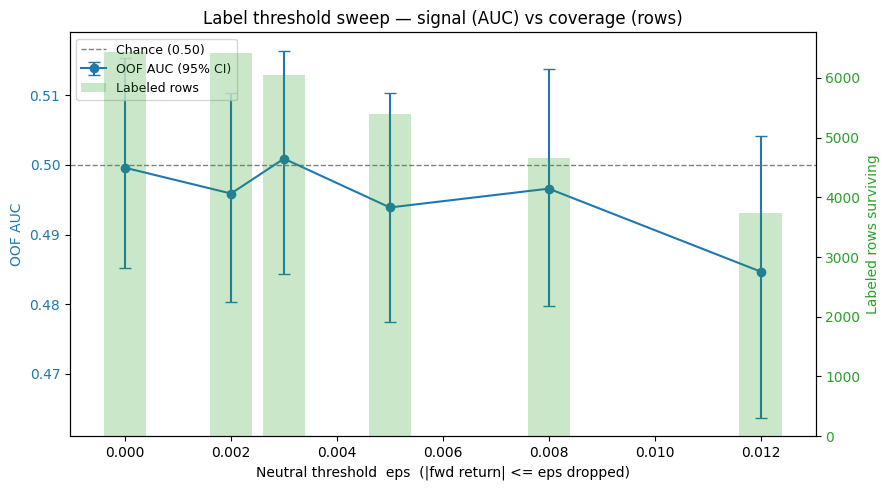

In [46]:
fig, ax1 = plt.subplots(figsize=(9, 5))

err = [sweep_df['auc'] - sweep_df['ci_lo'], sweep_df['ci_hi'] - sweep_df['auc']]
ax1.errorbar(sweep_df['eps'], sweep_df['auc'], yerr=err, marker='o',
             capsize=4, color='tab:blue', label='OOF AUC (95% CI)')
ax1.axhline(0.50, ls='--', color='grey', lw=1, label='Chance (0.50)')
ax1.set_xlabel('Neutral threshold  eps  (|fwd return| <= eps dropped)')
ax1.set_ylabel('OOF AUC', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')

ax2 = ax1.twinx()
ax2.bar(sweep_df['eps'], sweep_df['n_rows'], width=0.0008,
        alpha=0.25, color='tab:green', label='Labeled rows')
ax2.set_ylabel('Labeled rows surviving', color='tab:green')
ax2.tick_params(axis='y', labelcolor='tab:green')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=9)
ax1.set_title('Label threshold sweep — signal (AUC) vs coverage (rows)')
fig.tight_layout()
plt.show()


---
## Section 11: Volatility-Regime Model (Positive Control)

Section 10 established with confidence intervals that next-day direction is not predictable from these OHLCV-proxied features. But this raises a fair question: *is the pipeline broken, or is the signal simply absent?*

This section answers it with a **positive control**. Volatility clusters which are today's volatility strongly predicts tomorrow's. This is one of the most robust stylized facts in finance (the entire ARCH/GARCH literature rests on it). So if the feature engine, walk-forward, and evaluation are sound, re-aiming the exact same machinery at a volatility target should clear 0.50 decisively.



In [47]:
def add_vol_regime_label(matrix: pd.DataFrame,
                         horizon: int = 1,
                         window: int = 20) -> pd.DataFrame:

    df = matrix.sort_values(['ticker', 'date']).copy()
    parts = []
    for tk, g in df.groupby('ticker', sort=False):
        g = g.sort_values('date').copy()
        raw_range = (g['high'] - g['low']) / g['close'].replace(0, np.nan)
        fwd       = raw_range.shift(-horizon)                              # target (future)
        trail_med = raw_range.rolling(window, min_periods=max(5, window // 2)).median()
        g['vol_fwd_range'] = fwd
        g['vol_label']     = (fwd > trail_med).astype(float)
        g.loc[fwd.isna(), 'vol_label'] = np.nan                            # last `horizon` rows
        parts.append(g)
    return pd.concat(parts, ignore_index=True)


vol_labeled = add_vol_regime_label(feature_matrix,
                                   horizon=CFG.label_horizon_days, window=20)
print('vol_label balance:',
      vol_labeled['vol_label'].value_counts(dropna=True, normalize=True).round(3).to_dict())
print('dropped (no t+horizon):', int(vol_labeled['vol_label'].isna().sum()))


vol_label balance: {0.0: 0.521, 1.0: 0.479}
dropped (no t+horizon): 15


In [48]:
VOL_EXCLUDE = EXCLUDE_FROM_FEATURES | {'vol_fwd_range', 'vol_label'}

X_vol, y_vol, vol_feat_cols, meta_vol = prepare_xy(
    vol_labeled, label_col='vol_label', exclude=VOL_EXCLUDE)
folds_vol  = time_series_split_walk_forward(X_vol, y_vol, meta_vol, n_splits=CFG.cv_splits)
vol_result = train_walk_forward(X_vol, y_vol, folds_vol, CFG.xgb_params)

print('=== Volatility-regime walk-forward (per fold) ===')
for m in vol_result['per_fold_metrics']:
    a = f"{m['auc']:.4f}" if not np.isnan(m['auc']) else 'N/A'
    print(f"  fold {m['fold']}: acc={m['accuracy']:.4f}  AUC={a}  F1={m['f1']:.4f}")

_mask = np.isfinite(vol_result['oof_prob'])
vol_auc, vol_lo, vol_hi, _ = oof_auc_ci(y_vol.values[_mask], vol_result['oof_prob'][_mask])
vol_ci = [round(vol_lo, 4), round(vol_hi, 4)]
print(f"\nOOF AUC = {vol_auc:.4f}    95% CI [{vol_lo:.4f}, {vol_hi:.4f}]")
print('Verdict:',
      'positive' if vol_lo > 0.50
      else 'unexpected')

vol_prod_model = xgb.XGBClassifier(**CFG.xgb_params)
vol_prod_model.fit(X_vol, y_vol)
print('\nProduction vol model fitted on', X_vol.shape)


=== Volatility-regime walk-forward (per fold) ===
  fold 0: acc=0.5461  AUC=0.5695  F1=0.5165
  fold 1: acc=0.5428  AUC=0.5493  F1=0.4958
  fold 2: acc=0.5294  AUC=0.5548  F1=0.5708
  fold 3: acc=0.5931  AUC=0.6308  F1=0.5674
  fold 4: acc=0.6074  AUC=0.6610  F1=0.5895

OOF AUC = 0.5867    95% CI [0.5724, 0.6005]
Verdict: positive

Production vol model fitted on (7155, 131)


---
## Section 12: SHAP

SHAP tells you how much and in which direction each feature moved each prediction, with consistent, additive attributions.

I explain the volatility-regime modelhe one that demonstrably learned something. Running SHAP on a chance-level directional model would just be attributing noise with unnecessary precision.

This analysis also closes the loop on the our so-called hypothesis: if order-flow proxies (delta imbalance, aggression ratios, pattern confidence scores) are prominent in the SHAP importance ranking, it means these features do carry information but just about volatility, not direction.


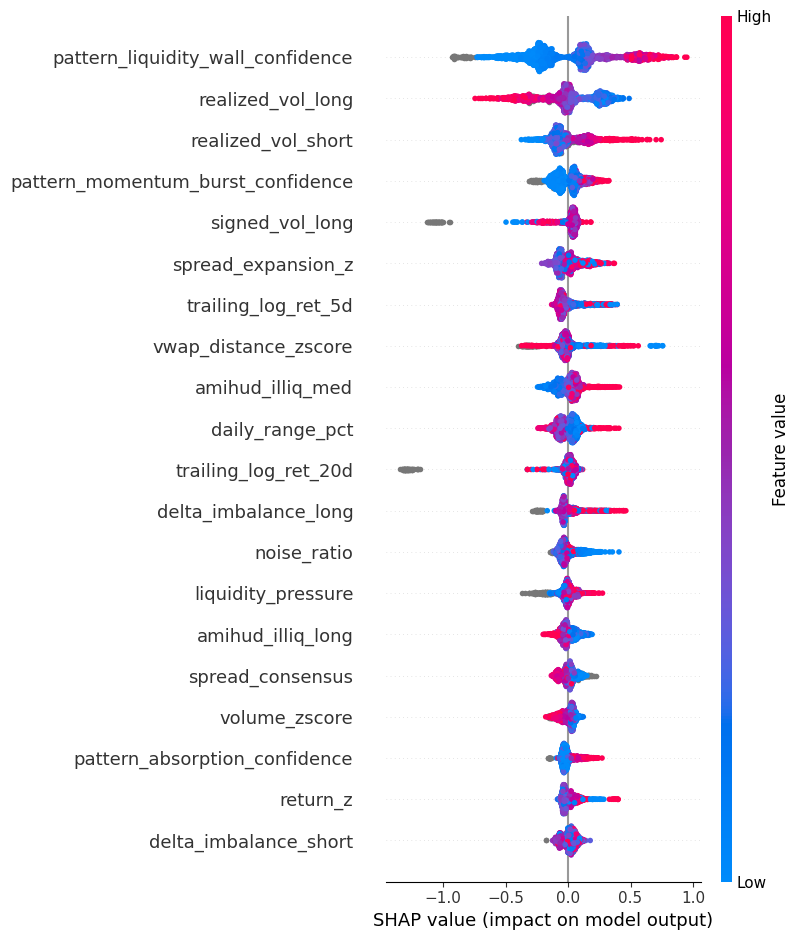


Top 15 features by mean |SHAP|:
pattern_liquidity_wall_confidence    0.2981
realized_vol_long                    0.1779
realized_vol_short                   0.1158
pattern_momentum_burst_confidence    0.0889
signed_vol_long                      0.0809
spread_expansion_z                   0.0737
trailing_log_ret_5d                  0.0693
vwap_distance_zscore                 0.0690
amihud_illiq_med                     0.0678
daily_range_pct                      0.0627
trailing_log_ret_20d                 0.0577
delta_imbalance_long                 0.0567
noise_ratio                          0.0545
liquidity_pressure                   0.0469
amihud_illiq_long                    0.0463


In [49]:
import shap

explainer = shap.TreeExplainer(vol_prod_model)
n_sample  = min(2000, len(X_vol))
X_shap    = X_vol.sample(n=n_sample, random_state=42)
shap_values = explainer.shap_values(X_shap)

# Beeswarm: direction + magnitude per feature
shap.summary_plot(shap_values, X_shap, max_display=20, show=True)

# Mean ranking
mean_abs = np.abs(shap_values).mean(axis=0)
shap_importance = (pd.Series(mean_abs, index=X_shap.columns)
                   .sort_values(ascending=False))
print('\nTop 15 features by mean |SHAP|:')
print(shap_importance.head(15).round(4).to_string())


---
## Section 13: Signal Engine

The signal engine turns the latest feature row per ticker into a compact, human and machine-readable interpretation. It is deliberately rule-based and transparent in which every field traces to a named feature and a threshold.


In [50]:
def _first(row, candidates, default=np.nan):

    for c in candidates:
        if c in row.index and pd.notna(row[c]):
            return row[c]
    return default

def _band(x, lo, hi, labels):

    if pd.isna(x):
        return 'unknown'
    return labels[0] if x < lo else (labels[2] if x > hi else labels[1])

def build_signal(row, model=None, feat_cols=None) -> dict:
    imb   = _first(row, ['delta_imbalance_med_mean', 'delta_imbalance_med'], 0.0)
    delta = _first(row, ['cum_delta_eod_normalized'], 0.0)
    spr_z = _first(row, ['spread_consensus_mean', 'spread_consensus'], 0.0)   # z-scored
    buy   = _first(row, ['buyer_aggression_med_mean', 'buyer_aggression_med'], np.nan)
    patt  = {k: row[k] for k in row.index
             if k.startswith('pattern_') and k.endswith('_confidence_max')}

    sig = {
        'ticker': row['ticker'],
        'date':   str(pd.to_datetime(row['date']).date()),

        'imbalance_signal':    _band(imb,   -0.15, 0.15, ['bearish', 'neutral', 'bullish']),
        'delta_signal':        _band(delta, -0.10, 0.10, ['distribution', 'balanced', 'accumulation']),
        'liquidity_condition': _band(spr_z, -0.75, 0.75, ['tight_spread', 'normal_spread', 'wide_spread']),
        'buyer_aggression':    None if pd.isna(buy) else round(float(buy), 3),
        'patterns_detected':   sorted(k.replace('pattern_', '').replace('_confidence_max', '')
                                      for k, v in patt.items() if pd.notna(v) and v > 0.5),
    }

    if model is not None and feat_cols is not None:
        x = pd.DataFrame([row.reindex(feat_cols).values], columns=feat_cols)
        p_high = float(model.predict_proba(x)[0, 1])
        sig['prediction'] = {
            'target': 'next_day_volatility_regime',
            'p_high_vol': round(p_high, 3),
            'p_low_vol':  round(1 - p_high, 3),
            'confidence': 'medium',
        }
    return sig


latest_rows = vol_labeled.sort_values('date').groupby('ticker', sort=False).tail(1)
signals = [build_signal(r, model=vol_prod_model, feat_cols=vol_feat_cols)
           for _, r in latest_rows.iterrows()]

print(f'Generated {len(signals)} signals (latest session per ticker). Example:')
print(json.dumps(signals[0], indent=2))


Generated 15 signals (latest session per ticker). Example:
{
  "ticker": "BSDE.JK",
  "date": "2026-05-21",
  "imbalance_signal": "neutral",
  "delta_signal": "balanced",
  "liquidity_condition": "wide_spread",
  "buyer_aggression": 0.524,
  "patterns_detected": [
    "absorption"
  ],
  "prediction": {
    "target": "next_day_volatility_regime",
    "p_high_vol": 0.252,
    "p_low_vol": 0.748,
    "confidence": "medium"
  }
}


---
## Section 14: Output Generation

I will turn the whole schema and findings into json that will, hopefully in the future if i am in motivation again, to perform AI analysis based on our findings for signal tracker.


In [51]:
import os, datetime as _dt

def emit_structured_output(signals, vol_ci=None, direction_ci=None) -> dict:
    return {
        'schema_version': '1.0',
        'generated_at':   _dt.datetime.now().isoformat(timespec='seconds'),
        'generated_for':  'KSPM AI narrative layer',
        'basket':         sorted({s['ticker'] for s in signals}),
        'data_provenance': {
            'source': 'yfinance OHLCV (daily + 5-min intraday)',
            'microstructure': 'PROXIED from OHLCV — no observed bid/offer or trade-by-trade tape',
            'caveat': ('Spread, imbalance, delta and aggression are academic estimators '
                       '(Roll / Corwin-Schultz / Abdi-Ranaldo / tick-rule), not real order-book '
                       'data. Narrative language should hedge accordingly.'),
        },
        'model_card': {
            'directional_model': {
                'status': 'tested; NOT predictable',
                'oof_auc_95ci': direction_ci,
                'note': 'Next-day direction CI includes 0.50 across all label thresholds.',
            },
            'active_model': {
                'target': 'next_day_volatility_regime',
                'oof_auc_95ci': vol_ci,
                'note': 'High-vol-day classifier; the only field with demonstrated predictive signal.',
            },
        },
        'signals': signals,
    }

structured_output = emit_structured_output(signals, vol_ci=vol_ci, direction_ci=None)

os.makedirs(CFG.output_dir, exist_ok=True)
out_path = os.path.join(CFG.output_dir, 'kspm_signals.json')
with open(out_path, 'w') as f:
    json.dump(structured_output, f, indent=2)

print(f'Structured output written to: {out_path}')
print(f'Payload: {len(structured_output["signals"])} signals + provenance + model_card')
print('\n preview (header + first signal) ')
_preview = {**structured_output, 'signals': structured_output['signals'][:1]}
print(json.dumps(_preview, indent=2))


Structured output written to: ./output/kspm_signals.json
Payload: 15 signals + provenance + model_card

 preview (header + first signal) 
{
  "schema_version": "1.0",
  "generated_at": "2026-05-21T02:45:07",
  "generated_for": "KSPM AI narrative layer",
  "basket": [
    "ADRO.JK",
    "ANTM.JK",
    "ASII.JK",
    "BBCA.JK",
    "BBNI.JK",
    "BBRI.JK",
    "BMRI.JK",
    "BSDE.JK",
    "GGRM.JK",
    "GOTO.JK",
    "ICBP.JK",
    "INCO.JK",
    "KLBF.JK",
    "TLKM.JK",
    "UNVR.JK"
  ],
  "data_provenance": {
    "source": "yfinance OHLCV (daily + 5-min intraday)",
    "microstructure": "PROXIED from OHLCV \u2014 no observed bid/offer or trade-by-trade tape",
    "caveat": "Spread, imbalance, delta and aggression are academic estimators (Roll / Corwin-Schultz / Abdi-Ranaldo / tick-rule), not real order-book data. Narrative language should hedge accordingly."
  },
  "model_card": {
    "directional_model": {
      "status": "tested; NOT predictable",
      "oof_auc_95ci": null,
   